# 2026-10-09 Orthogonal distance to KE01: combined PDFs by stage, stellar density and radius

Copied from `20261008_check_orthogonal_distance_to_KE01_BPT_PDFs_SF_NSF_TNSF_partition_by_stage.ipynb`; source unchanged. Retain only its last figure (original cell 23/23): three stage rows (pre-peak, close-to-peak, post-peak) and two BPT columns (NII, SII).

Show the full sample first, then repeat this figure independently for:

- Five stellar-density intervals in $\log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$: 7.0-7.5, 7.5-8.0, 8.0-8.5, 8.5-9.0, 9.0-9.5.
- Five deprojected radial intervals in $R/R_e$: 0.0-0.5, 0.5-1.0, 1.0-1.5, 1.5-2.0, 2.0-2.5. Use the inherited elliptical effective-radius geometry, including the minimum component radius for combined products.

Every interval is lower-inclusive and upper-exclusive. These are separate binning series, not joint density-radius cuts. Use the original full-sample distance histogram edges in every figure; each figure shares its density scale across its six panels.

Four catalogue curves remain: **SF (blue)**, **NSF (orange)**, **TNSF (red)**, and **NSF-TNSF (green)**. Preserve the source selections: usable disc; inclination <80 degrees; finite mass and geometry; unmasked gas-bin footprint; strict finite `SNR_POSTFIT > 25`; corrected positive paired BPT ratios. SF requires finite HII SFR, EW(Halpha)>6 Angstrom and finite intrinsic Halpha dispersion <45 km/s. NSF is the Balmer-detected complement of SF. TNSF requires NSF with `NII_BPT == 3` and `SII_BPT` in `{2, 3}`. NSF-TNSF is the disjoint NSF remainder.

For each panel, SF uses its own finite count; NSF and both components share that panel's finite NSF count **after the bin cut**. Thus TNSF + NSF-TNSF equals NSF bin by bin. Empty panels report unavailable normalization. Print each curve's count, range and median before `plt.show()`; no figures are saved to disk by the notebook.

## Distance convention

Let $x=\log_{10}([\mathrm{NII}]/\mathrm{H}\alpha)$ or $\log_{10}(([\mathrm{SII}]6716+[\mathrm{SII}]6730)/\mathrm{H}\alpha)$, and $y=\log_{10}([\mathrm{OIII}]/\mathrm{H}\beta)$. Use the red KE01 curves from [Kewley et al. (2001), equations 5--6](https://arxiv.org/pdf/astro-ph/0106324):

$$f_{\mathrm{NII}}(u)=\frac{0.61}{u-0.47}+1.19,\quad u<0.47,$$
$$f_{\mathrm{SII}}(u)=\frac{0.72}{u-0.32}+1.30,\quad u<0.32.$$

The **orthogonal magnitude** is the global shortest Euclidean distance from **every selected finite BPT point, wherever it lies**, to the red KE01 demarcation curve in log-ratio space. Upper-right points are included, even when their observed $x$ is at or beyond the curve's vertical asymptote.

Here $(x,y)$ is the observed point, while $(u,f(u))$ is a candidate closest point on the red curve. The restriction $u<b$ describes the **target curve only** ($b=0.47$ for NII, $b=0.32$ for SII); it imposes **no restriction on the observed $x$ or $y$**. This target is sometimes called the hyperbola's left-hand branch. The separate algebraic branch at $u>b$ is not the red BPT demarcation curve used here.

$$|d_\perp|=\min_{u<b}\sqrt{(x-u)^2+[y-f(u)]^2}.$$

For each observed point, search the entire red demarcation curve for its nearest point, then measure the length of the connecting segment. Both axes have equal metric weight; units are dex in this two-dimensional log-ratio metric. This is a geometric diagnostic, with no uncertainty weighting. The target curve is not truncated at the plotting endpoints (-2 or 0.3), and observed points outside a conventional BPT window remain included. Far-tail distances extrapolate the analytical fit geometrically; they do not establish the physical validity of a classification there.

**Sign:** negative if $x<b$ and $y<f(x)$ (below/left side of the red curve); positive otherwise. Observed points with $x\ge b$ still receive their shortest distance to the red curve, with a positive sign; they are not discarded and their distance is not evaluated against the separate algebraic branch. Points on the red curve have zero distance. Positive distance does not by itself identify an excitation mechanism. The plotted x axis is the **signed distance itself**, on a linear axis, with a zero reference line; do not take its logarithm.

**Exact projection for any observed $(x,y)$:** writing the target red curve as $(u,v)=(b-t,c-a/t)$ with $t>0$, stationary squared distances obey

$$t^4+(x-b)t^3+a(c-y)t-a^2=0.$$

Find every positive real root and choose the global smallest distance. Since squared distance diverges as $t\to0^+$ and $t\to\infty$, a minimum is among those stationary points. Multiple local minima are possible; selecting only one optimizer root could fail. Identical ratio pairs are solved once for efficiency, then expanded back to every spaxel without changing weights. Verify the closest point lies on the branch and the displacement is perpendicular to its tangent.

**Histogram normalization:** pooled-spaxel density per dex of signed distance. All four curves share the same full-range bin edges for each diagram across all stages, without clipping. SF and NSF each integrate to 1 when nonempty. Within each stage and diagram, let $n_{C,i}$ be the count in distance bin $i$, $\Delta d_i$ its width, and $N_C$ the total **finite paired distances** in catalogue $C$. Plot

$$h_{\rm SF,i}=\frac{n_{\rm SF,i}}{N_{\rm SF}\Delta d_i},\qquad
h_{\rm NSF,i}=\frac{n_{\rm NSF,i}}{N_{\rm NSF}\Delta d_i},$$
$$h_{\rm TNSF,i}=\frac{n_{\rm TNSF,i}}{N_{\rm NSF}\Delta d_i},\qquad
h_{\rm NSF-TNSF,i}=\frac{n_{\rm NSF-TNSF,i}}{N_{\rm NSF}\Delta d_i}.$$

Both NSF components use the **same finite NSF denominator**, rather than being independently normalized to 1. Their counts partition NSF exactly, so red plus green equals orange in every bin (density equality up to floating-point roundoff). Their integrals are the finite-distance fractions $N_{\rm TNSF}/N_{\rm NSF}$ and $N_{\rm NSF-TNSF}/N_{\rm NSF}$ and sum to 1. Denominators are specific to the stage and BPT diagram; NII and SII can have different paired supports. An empty component is a zero curve when NSF is nonempty. If NSF is empty, all three NSF normalizations are undefined and reported as unavailable. The same rule applies to the full-sample and interval-selected combined 3-by-2 figures.

Print counts, normalization denominator, integral, signed range and median before each combined figure. Larger footprints carry more weight; spaxels sharing a fitted gas bin are not independent spectra. SF and NSF are disjoint, while the displayed NSF parent overlaps its two components. These are descriptive distributions without propagated measurement errors or an evolutionary inference. Figures use `plt.show()` only; FITS products are unchanged.

**TNSF definition update (2026-10-08):** `NSF & (NII_BPT == 3) & np.isin(SII_BPT, [2, 3])`.
SII code 2 is LINER and code 3 is Seyfert; this joint requirement applies
to TNSF in both BPT diagrams.
The existing SF, NSF, usable-disc footprint, strict SNR_POSTFIT cut,
support rules, and weighting conventions are retained.


In [1]:
from pathlib import Path
import hashlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy import units as u
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "v3tk_v7.6.8").is_dir():
    PROJECT_ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = ("{galid}_gas_bin_maps_further.fits", "{galid}_gas_BIN_maps_further.fits")
EW_FILE_PATTERNS = ("{galid}_proxy_EW_maps_further.fits", "{galid}_proxy_EW_maps.fits")
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"
MASS_HDU, BIN_HDU_MASS, BIN_HDU_GAS = "LOGMASS_SURFACE_DENSITY", "BINID", "BIN_ID"
SFR_HDU, EW_HDU = "LOGSFR_SURFACE_DENSITY_HII", "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU, HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA", "HA6562_SIGMA_CORR"
MASK_TABLE_HDU, MASK_COLUMN = "MASKFILE", "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"
EW_HA_MIN, HALPHA_SIGMA_MAX, SFH_SNR_POSTFIT_MIN = 6.0, 45.0, 25.0
I_MAX_PRIMARY, WCS_TOLERANCE_ARCSEC = 80.0, 0.05
BALMER_LINES = ("HB4861", "HA6562")
REASON_LABELS = ("BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
                 "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45")
CATEGORY_ORDER = ("SF", "NSF", "TNSF", "NSF-TNSF")
OBSERVABLE_ORDER = ("NII", "SII")
KE01_PARAMETERS = {"NII": (0.61, 0.47, 1.19), "SII": (0.72, 0.32, 1.30)}
PROJECTION_CHUNK_SIZE = 8192
N_HIST_BINS = 60
CATEGORY_COLORS = dict(zip(CATEGORY_ORDER, ("#2166ac", "#e08214", "#b2182b", "#1b9e3c")))
CATEGORY_STYLES = dict(zip(CATEGORY_ORDER, ("-", "-", "-", "-")))
OBSERVABLE_LABELS = {d: rf"Signed orthogonal distance to KE01 ({d} BPT) [dex]" for d in OBSERVABLE_ORDER}
OBSERVABLE_TITLES = {d: d + " BPT signed orthogonal distance to KE01" for d in OBSERVABLE_ORDER}
mpl.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": False})
SOURCE_NOTEBOOK_SHA256 = "cc47f41c355634dbcfc95b887c87b59ec06295bb925a4fd12b336cbd770f90af"
print("Source notebook SHA256:", SOURCE_NOTEBOOK_SHA256)
print("Signed shortest distance to KE01 left branch in equally weighted log-ratio space")

SIGMA_STAR_EDGES = np.arange(7.0, 10.0, 0.5)
RADIAL_EDGES = np.arange(0.0, 3.0, 0.5)


Source notebook SHA256: cc47f41c355634dbcfc95b887c87b59ec06295bb925a4fd12b336cbd770f90af
Signed shortest distance to KE01 left branch in equally weighted log-ratio space


## Inherited catalogue, geometry and selection helpers

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "sigma_intrinsic": sigma_intrinsic,
        "gas_bin_id": gas_bin,
        "ew_ha": ew_ha,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    tnsf = nsf & (nii == 3) & np.isin(sii, [2, 3])
    assert not np.any(tnsf & ~nsf)
    assert np.all(nii[tnsf] == 3)
    assert np.isin(sii[tnsf], [2, 3]).all()
    maps.update({
        "tnsf_mask": tnsf, "nii_bpt_class": nii, "sii_bpt_class": sii,
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": first_existing([folder / MASS_FILE_PATTERN.format(galid=galid)]),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": first_existing([folder / MASK_FILE_PATTERN.format(galid=galid)]),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)



## Global orthogonal projection helper

Solve all stationary roots on the full physical left-hand branch; use the minimum distance and verify tangent orthogonality.

In [4]:
def project_ke01_unique(pairs, diagram):
    """Global projection from all positive real stationary roots, in chunks."""
    a, b, c = KE01_PARAMETERS[diagram]
    signed = np.empty(len(pairs), dtype=float)
    closest = np.empty_like(pairs)
    max_residual = 0.0
    for start in range(0, len(pairs), PROJECTION_CHUNK_SIZE):
        part = pairs[start:start + PROJECTION_CHUNK_SIZE]
        x, y = part.T
        # Companion matrices of t^4 + (x-b)t^3 + a(c-y)t - a^2.
        companion = np.zeros((len(part), 4, 4), dtype=float)
        companion[:, 0, 0] = b - x
        companion[:, 0, 2] = a * (y - c)
        companion[:, 0, 3] = a * a
        companion[:, 1, 0] = companion[:, 2, 1] = companion[:, 3, 2] = 1.0
        roots = np.linalg.eigvals(companion)
        real_positive = ((np.abs(roots.imag) <= 1e-9 * np.maximum(1.0, np.abs(roots.real)))
                         & (roots.real > 0))
        if not real_positive.any(axis=1).all():
            raise ArithmeticError('No positive real stationary root')
        t = np.where(real_positive, roots.real, np.nan)
        u, v = b - t, c - a / t
        squared = (x[:, None] - u)**2 + (y[:, None] - v)**2
        squared = np.where(real_positive, squared, np.inf)
        best = np.argmin(squared, axis=1)
        indices = np.arange(len(part))
        tb = t[indices, best]
        ub, vb = u[indices, best], v[indices, best]
        magnitude = np.sqrt(squared[indices, best])
        # Normal = (a/t^2, 1); test orthogonality with unit tangent (1,-a/t^2).
        slope = -a / tb**2
        residual = np.abs(((x - ub) + (y - vb) * slope) / np.hypot(1.0, slope))
        relative = residual / np.maximum(1.0, magnitude)
        max_residual = max(max_residual, float(relative.max(initial=0)))
        assert np.all(relative < 1e-8), 'Projection is not perpendicular'
        assert np.all(tb > 0) and np.all(ub < b)
        assert np.allclose(vb, c - a / tb, atol=1e-12, rtol=1e-12)
        below = np.zeros(len(part), dtype=bool)
        left = x < b
        below[left] = y[left] < c + a / (x[left] - b)
        distances = np.where(below, -magnitude, magnitude)
        distances[magnitude < 1e-12] = 0.0
        signed[start:start + len(part)] = distances
        closest[start:start + len(part)] = np.column_stack((ub, vb))
    return signed, closest, max_residual

def signed_ke01_distance(x, y, selected, diagram):
    paired = selected & np.isfinite(x) & np.isfinite(y)
    result = np.full(x.shape, np.nan, dtype=float)
    pairs = np.column_stack((x[paired], y[paired]))
    if not len(pairs):
        return result, {'N_paired': 0, 'N_unique_pairs': 0, 'max_orthogonality_residual': 0.0}
    unique, inverse = np.unique(pairs, axis=0, return_inverse=True)
    distances, _, residual = project_ke01_unique(unique, diagram)
    assert np.isfinite(distances).all()
    result[paired] = distances[inverse]
    assert np.array_equal(np.isfinite(result), paired)
    return result, {'N_paired': len(pairs), 'N_unique_pairs': len(unique),
                    'max_orthogonality_residual': residual}


## Load live corrected ratios and compute paired orthogonal distances

Retain the inherited shape/unit/WCS and corrected-luminosity checks. Compute distances only on the union of selected regions, and list missing or invalid products explicitly.

In [5]:
def positive_log10(values):
    result = np.full(values.shape, np.nan, dtype=float)
    keep = np.isfinite(values) & (values > 0)
    result[keep] = np.log10(values[keep])
    return result

def corrected_observables(row, shape):
    lines = ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730")
    with fits.open(row.sfr_path, memmap=True) as hdul:
        flux = {}
        for line in lines:
            hdu = hdul[line + "_FLUX_CORR"]
            if hdu.data.shape != shape:
                raise ValueError(f"{row.GALID}: corrected {line} shape mismatch")
            if hdu.header.get("BUNIT", "").strip() != "1e-20 erg s-1 cm-2":
                raise ValueError(f"{row.GALID}: unexpected corrected {line} flux unit")
            flux[line] = np.asarray(hdu.data, dtype=float).copy()
        distance = float(hdul[0].header["DIST_MPC"])
        scales = proj_plane_pixel_scales(WCS(hdul[BIN_HDU_GAS].header).celestial)
        if scales.size != 2 or not np.all(np.isfinite(scales) & (scales > 0)) or not (np.isfinite(distance) and distance > 0):
            raise ValueError(f"{row.GALID}: invalid distance or celestial pixel scales")
        area_kpc2 = float(np.prod(np.deg2rad(scales) * distance * 1000))
        distance_cm = (distance * u.Mpc).to_value(u.cm)
        ha_surface = flux["HA6562"] * 1e-20 * 4 * np.pi * distance_cm**2 / area_kpc2
        provenance = {"DIST_MPC": distance, "pixel_area_kpc2": area_kpc2,
                      "DUSTLAW": hdul[0].header.get("DUSTLAW"), "BPTLIMIT": hdul[0].header.get("BPTLIMIT")}
        # Independent cross-check against the stored corrected luminosity map
        # only on Balmer detections (the stored map substitutes limits elsewhere).
        luminosity = np.asarray(hdul["HALPHA_LUMINOSITY_CORR"].data, dtype=float)
    variables = {"Halpha": positive_log10(ha_surface)}
    flux_to_surface = 1e-20 * 4 * np.pi * distance_cm**2 / area_kpc2
    variables["OIII5006_SB"] = positive_log10(flux["OIII5006"] * flux_to_surface)
    variables["NII6583_SB"] = positive_log10(flux["NII6583"] * flux_to_surface)
    sii_good = (np.isfinite(flux["SII6716"]) & (flux["SII6716"] > 0)
                & np.isfinite(flux["SII6730"]) & (flux["SII6730"] > 0))
    sii_surface = np.full(shape, np.nan)
    sii_surface[sii_good] = (flux["SII6716"][sii_good] + flux["SII6730"][sii_good]) * flux_to_surface
    variables["SII_SUM_SB"] = positive_log10(sii_surface)
    for key, numerator_lines, denominator in (
        ("O3", ("OIII5006",), "HB4861"),
        ("N2", ("NII6583",), "HA6562"),
        ("S2", ("SII6716", "SII6730"), "HA6562"),
    ):
        good = np.isfinite(flux[denominator]) & (flux[denominator] > 0)
        numerator = np.zeros(shape, dtype=float)
        for line in numerator_lines:
            good &= np.isfinite(flux[line]) & (flux[line] > 0)
            numerator += flux[line]
        ratio = np.full(shape, np.nan)
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            ratio[good] = numerator[good] / flux[denominator][good]
        variables[key] = positive_log10(ratio)
    # Common conversion must cancel in the N2/S2 luminosity surface-density ratios.
    for surface_key, ratio_key in (("NII6583_SB", "N2"), ("SII_SUM_SB", "S2")):
        good = np.isfinite(variables[surface_key]) & np.isfinite(variables["Halpha"])
        assert np.array_equal(good, np.isfinite(variables[ratio_key]))
        assert np.allclose(variables[surface_key][good] - variables["Halpha"][good],
                           variables[ratio_key][good], rtol=0, atol=1e-12)
    return variables, provenance, luminosity, ha_surface * area_kpc2

VALUES_BY_GALAXY, qc_rows, count_rows, provenance_rows, projection_rows = [], [], [], [], []
for row in candidates.itertuples(index=False):
    flags = []
    for label in ("mass", "sfr", "ew", "mask", "sfh"):
        path = getattr(row, label + "_path")
        if not isinstance(path, Path) or not path.exists():
            flags.append("missing_" + label + "_product")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            keep = maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
            sf, nsf, tnsf = (maps[key] & keep for key in ("sf_mask", "nsf_mask", "tnsf_mask"))
            remainder = nsf & ~tnsf
            selections = dict(zip(CATEGORY_ORDER, (sf, nsf, tnsf, remainder)))
            assert not np.any(tnsf & remainder)
            assert np.array_equal(tnsf | remainder, nsf)
            assert not np.any(sf & nsf)
            assert np.array_equal(tnsf, nsf & (maps["nii_bpt_class"] == 3) & np.isin(maps["sii_bpt_class"], [2, 3]))
            variables, provenance, stored_lum, direct_lum = corrected_observables(row, keep.shape)
            detected = keep & maps["balmer_detected_mask"] & np.isfinite(direct_lum) & (direct_lum > 0)
            if not detected.any() or not np.allclose(stored_lum[detected], direct_lum[detected], rtol=1e-6, atol=0):
                raise ValueError("stored/direct corrected Halpha luminosity disagreement")
            # Compute both distances on the union of selected footprints, keeping pairs joint.
            ratio_maps = variables
            variables, galaxy_projection = {}, []
            union_selected = np.logical_or.reduce(list(selections.values()))
            for diagram, ratio_key in (("NII", "N2"), ("SII", "S2")):
                distances, diagnostic = signed_ke01_distance(ratio_maps[ratio_key], ratio_maps["O3"], union_selected, diagram)
                variables[diagram] = distances
                galaxy_projection.append({"GALID": row.GALID, "stage": row.stage, "diagram": diagram, **diagnostic})
            galaxy_values, galaxy_counts = [], []
            for category, mask in selections.items():
                assert not np.any(mask & ~keep)
                for observable, values in variables.items():
                    selected = values[mask]
                    finite_mask = mask & np.isfinite(values)
                    finite = values[finite_mask]
                    # Keep both coordinates aligned with each original finite distance.
                    galaxy_values.append({"GALID": row.GALID, "stage": row.stage, "category": category,
                                          "observable": observable, "values": finite,
                                          "log_sigma_star": maps["log_sigma_star"][finite_mask],
                                          "radius_re": maps["radius_re"][finite_mask]})
                    galaxy_counts.append({"GALID": row.GALID, "stage": row.stage, "category": category,
                        "observable": observable, "N_selected": int(mask.sum()), "N_finite": finite.size,
                        "N_unavailable": int(mask.sum()) - finite.size,
                        "N_gas_bins": int(np.unique(maps["gas_bin_id"][mask & np.isfinite(values)]).size)})
            projection_rows.extend(galaxy_projection)
            VALUES_BY_GALAXY.extend(galaxy_values)
            count_rows.extend(galaxy_counts)
            provenance_rows.append({"GALID": row.GALID, "stage": row.stage, **maps["detection_provenance"], **provenance})
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    qc_rows.append({"GALID": row.GALID, "components": row.components, "stage": row.stage,
                    "inclination_deg": row.inclination, "QC_flag": ";".join(flags) if flags else "OK"})

SAMPLE_QC = pd.DataFrame(qc_rows)
MEASUREMENT_COUNTS = pd.DataFrame(count_rows)
PROVENANCE = pd.DataFrame(provenance_rows)
display(SAMPLE_QC)
display(PROVENANCE)
for stage in STAGE_ORDER:
    ids = SAMPLE_QC.loc[SAMPLE_QC.stage.eq(stage) & SAMPLE_QC.QC_flag.eq("OK"), "GALID"].tolist()
    print(f"{STAGE_LABELS[stage]} ({len(ids)} passing products): {', '.join(ids)}")
    if not ids:
        raise RuntimeError(f"No {stage} products pass QC")
display(MEASUREMENT_COUNTS.groupby(["stage", "category", "observable"], observed=True)[
    ["N_selected", "N_finite", "N_unavailable", "N_gas_bins"]].sum())

PROJECTION_QC = pd.DataFrame(projection_rows)
display(PROJECTION_QC)
assert PROJECTION_QC.max_orthogonality_residual.lt(1e-8).all()


Pre-peak (8 passing products): NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8
Close-to-peak (5 passing products): NGC4298, NGC4424, NGC4501, NGC4654, NGC4694
Post-peak (13 passing products): IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4569, NGC4580, NGC4606, NGC4698


,GALID,components,stage,inclination_deg,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,OK
5,IC3392,IC3392,post-peak,68.0,OK
6,NGC4064,NGC4064,post-peak,70.0,OK
7,NGC4293,NGC4293,post-peak,67.0,OK
8,NGC4380,NGC4380,post-peak,61.0,OK
9,NGC4394,NGC4394,post-peak,32.0,OK


,GALID,stage,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW,DIST_MPC,pixel_area_kpc2
0,NGC4298,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
1,NGC4424,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
2,NGC4501,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
3,NGC4654,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
4,NGC4694,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
5,IC3392,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
6,NGC4064,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
7,NGC4293,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
8,NGC4380,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
9,NGC4394,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256


N_selected  ...  N_gas_bins
stage         category observable              ...            
close-to-peak NSF      NII             488865  ...       55574
                       SII             488865  ...       55556
              NSF-TNSF NII             482648  ...       53486
                       SII             482648  ...       53468
              SF       NII             720842  ...       56923
                       SII             720842  ...       56923
              TNSF     NII               6217  ...        2088
                       SII               6217  ...        2088
post-peak     NSF      NII             815887  ...      129673
                       SII             815887  ...      129346
              NSF-TNSF NII             721107  ...      108520
                       SII             721107  ...      108193
              SF       NII             222427  ...       23182
                       SII             222427  ...       23182
              TNSF     NII              94780  ...       21153
                       SII              94780  ...       21153
pre-peak      NSF      NII             929104  ...       53651
                       SII             929104  ...       53650
              NSF-TNSF NII             920252  ...       52976
                       SII             920252  ...       52975
              SF       NII            1420915  ...       89280
                       SII            1420915  ...       89280
              TNSF     NII               8852  ...         675
                       SII               8852  ...         675

[24 rows x 4 columns]

,GALID,stage,diagram,N_paired,N_unique_pairs,max_orthogonality_residual
0,NGC4298,close-to-peak,NII,181088,10903,1.777981e-15
1,NGC4298,close-to-peak,SII,181088,10903,1.880363e-15
2,NGC4424,close-to-peak,NII,46409,4494,1.269734e-15
3,NGC4424,close-to-peak,SII,46364,4492,1.727410e-15
4,NGC4501,close-to-peak,NII,512493,68356,2.094586e-15
5,NGC4501,close-to-peak,SII,512298,68348,2.469512e-15
6,NGC4654,close-to-peak,NII,438594,22938,1.578091e-15
7,NGC4654,close-to-peak,SII,438594,22938,1.903052e-15
8,NGC4694,close-to-peak,NII,29155,5806,1.808111e-15
9,NGC4694,close-to-peak,SII,29129,5798,2.285758e-15


## Common distance bins and additive histogram normalization

Keep the original full-sample histogram edges for all figures. The SF denominator is its own finite count; NSF and its two components share the finite NSF count in the selected interval. Signed distance remains linear.


In [6]:
POOLED = {}
for stage in STAGE_ORDER:
    for observable in OBSERVABLE_ORDER:
        for category in CATEGORY_ORDER:
            arrays = [r["values"] for r in VALUES_BY_GALAXY if r["stage"] == stage
                      and r["observable"] == observable and r["category"] == category]
            POOLED[stage, observable, category] = np.concatenate(arrays) if arrays else np.array([])
COMMON_EDGES = {}
for observable in OBSERVABLE_ORDER:
    arrays = [v for (stage, obs, cat), v in POOLED.items() if obs == observable and v.size]
    if not arrays:
        raise RuntimeError(f"No finite paired distances for {observable}")
    lo = min(v.min() for v in arrays)
    hi = max(v.max() for v in arrays)
    if lo == hi:
        lo, hi = lo - 0.5, hi + 0.5
    COMMON_EDGES[observable] = np.linspace(lo, hi, N_HIST_BINS + 1)
    print(f"{observable}: full signed-distance bin range [{lo:.6g}, {hi:.6g}], {N_HIST_BINS} bins")

def partition_histograms(values_by_category, edges):
    widths = np.diff(edges)
    counts = {category: np.histogram(values_by_category[category], bins=edges)[0]
              for category in CATEGORY_ORDER}
    sizes = {category: values_by_category[category].size for category in CATEGORY_ORDER}
    for category in CATEGORY_ORDER:
        assert counts[category].sum() == sizes[category]
    assert np.array_equal(counts["TNSF"] + counts["NSF-TNSF"], counts["NSF"])
    assert sizes["TNSF"] + sizes["NSF-TNSF"] == sizes["NSF"]
    densities, denominators, integrals = {}, {}, {}
    for category in CATEGORY_ORDER:
        denominator = sizes["SF"] if category == "SF" else sizes["NSF"]
        denominators[category] = denominator
        densities[category] = (counts[category] / (denominator * widths)
                               if denominator else np.zeros_like(widths))
        integrals[category] = (float(np.sum(densities[category] * widths))
                              if denominator else np.nan)
        if denominator:
            assert np.isclose(integrals[category], sizes[category] / denominator)
    assert np.allclose(densities["TNSF"] + densities["NSF-TNSF"],
                       densities["NSF"], rtol=1e-12, atol=1e-14)
    return densities, denominators, integrals



NII: full signed-distance bin range [-1.99994, 1.10146], 60 bins
SII: full signed-distance bin range [-1.71894, 0.913879], 60 bins


## Combined six-panel PDF helper

Retain the source final-cell layout and styles. Apply each interval to aligned spaxel coordinates before pooling and normalization.


In [7]:
def pool_interval(coordinate, lower, upper):
    pooled = {}
    for stage in STAGE_ORDER:
        for diagram in OBSERVABLE_ORDER:
            for category in CATEGORY_ORDER:
                arrays = []
                for record in VALUES_BY_GALAXY:
                    if (record["stage"] != stage or record["observable"] != diagram
                            or record["category"] != category):
                        continue
                    values, coord = record["values"], record[coordinate]
                    assert values.shape == coord.shape
                    selected = np.isfinite(coord) & (coord >= lower) & (coord < upper)
                    arrays.append(values[selected])
                pooled[stage, diagram, category] = np.concatenate(arrays) if arrays else np.array([])
    return pooled

def plot_combined_pdf(pooled, selection_label):
    fig, axes = plt.subplots(3, 2, figsize=(16, 16), sharex="col", sharey=True, layout="constrained")
    combined_checks = []
    combined_max_density = 0.0
    for i, stage in enumerate(STAGE_ORDER):
        for j, diagram in enumerate(OBSERVABLE_ORDER):
            ax = axes[i, j]
            edges = COMMON_EDGES[diagram]
            values_by_category = {category: pooled[stage, diagram, category] for category in CATEGORY_ORDER}
            densities, denominators, integrals = partition_histograms(values_by_category, edges)
            print(f"\n{selection_label} | {STAGE_LABELS[stage]} | {diagram} | combined PDF")
            for category in CATEGORY_ORDER:
                values = values_by_category[category]
                denominator, integral = denominators[category], integrals[category]
                if values.size:
                    print(f"{category}: N={values.size:,}; distance range=[{values.min():.6g}, {values.max():.6g}] dex; "
                          f"median={np.median(values):.6g} dex; denominator={denominator:,}; PDF integral={integral:.6g}")
                else:
                    print(f"{category}: N=0; denominator={denominator:,}; integral={integral}; no finite paired distances")
                if denominator:
                    density = densities[category]
                    combined_max_density = max(combined_max_density, float(density.max()))
                    ax.stairs(density, edges, color=CATEGORY_COLORS[category], linestyle=CATEGORY_STYLES[category],
                              linewidth=1.8, label=f"{category} (N={values.size:,}; area={integral:.3f})")
                else:
                    ax.plot([], [], color=CATEGORY_COLORS[category], label=category + " (normalization unavailable)")
                combined_checks.append(not denominator or np.isclose(integral, values.size / denominator))
            print("Bin-by-bin check passed: TNSF + NSF-TNSF = NSF")
            ax.axvline(0.0, color="black", linewidth=1.1, linestyle=":", label="KE01: distance = 0")
            ax.set_xlim(min(edges[0], 0.0), max(edges[-1], 0.0))
            ax.set_title(f"{STAGE_LABELS[stage]} | {diagram} BPT", fontsize=14)
            if i == len(STAGE_ORDER) - 1:
                ax.set_xlabel(OBSERVABLE_LABELS[diagram])
            if j == 0:
                ax.set_ylabel("Density [dex$^{-1}$]")
            ax.legend(frameon=False, fontsize=9, loc="best")
            ax.grid(alpha=0.2)
    axes[0, 0].set_ylim(0, max(1.0, combined_max_density * 1.08))
    fig.suptitle("Orthogonal distance to KE01 | corrected ratios | SNR_POSTFIT > 25\n" + selection_label, fontsize=16)
    assert axes.shape == (3, 2)
    assert len(combined_checks) == len(STAGE_ORDER) * len(OBSERVABLE_ORDER) * len(CATEGORY_ORDER)
    assert all(combined_checks)
    plt.show()
    plt.close(fig)
    print("COMBINED_KE01_DISTANCE_PDF_VALIDATION_OK:", selection_label, "| 3 rows x 2 columns; 24 distributions; additive NSF components")


## Full sample: retained source final plot



Full sample: no stellar-density or radial cut | Pre-peak | NII | combined PDF
SF: N=1,420,915; distance range=[-1.11565, -0.222761] dex; median=-0.566365 dex; denominator=1,420,915; PDF integral=1
NSF: N=923,230; distance range=[-1.28191, 0.673442] dex; median=-0.281549 dex; denominator=923,230; PDF integral=1
TNSF: N=8,852; distance range=[0.0402216, 0.673442] dex; median=0.184696 dex; denominator=923,230; PDF integral=0.00958808
NSF-TNSF: N=914,378; distance range=[-1.28191, 0.647383] dex; median=-0.283219 dex; denominator=923,230; PDF integral=0.990412
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

Full sample: no stellar-density or radial cut | Pre-peak | SII | combined PDF
SF: N=1,420,915; distance range=[-1.23076, -0.00709875] dex; median=-0.441576 dex; denominator=1,420,915; PDF integral=1
NSF: N=923,217; distance range=[-1.37401, 0.686265] dex; median=-0.122681 dex; denominator=923,217; PDF integral=1
TNSF: N=8,852; distance range=[0.0252193, 0.501186] dex; median=0.195622 de

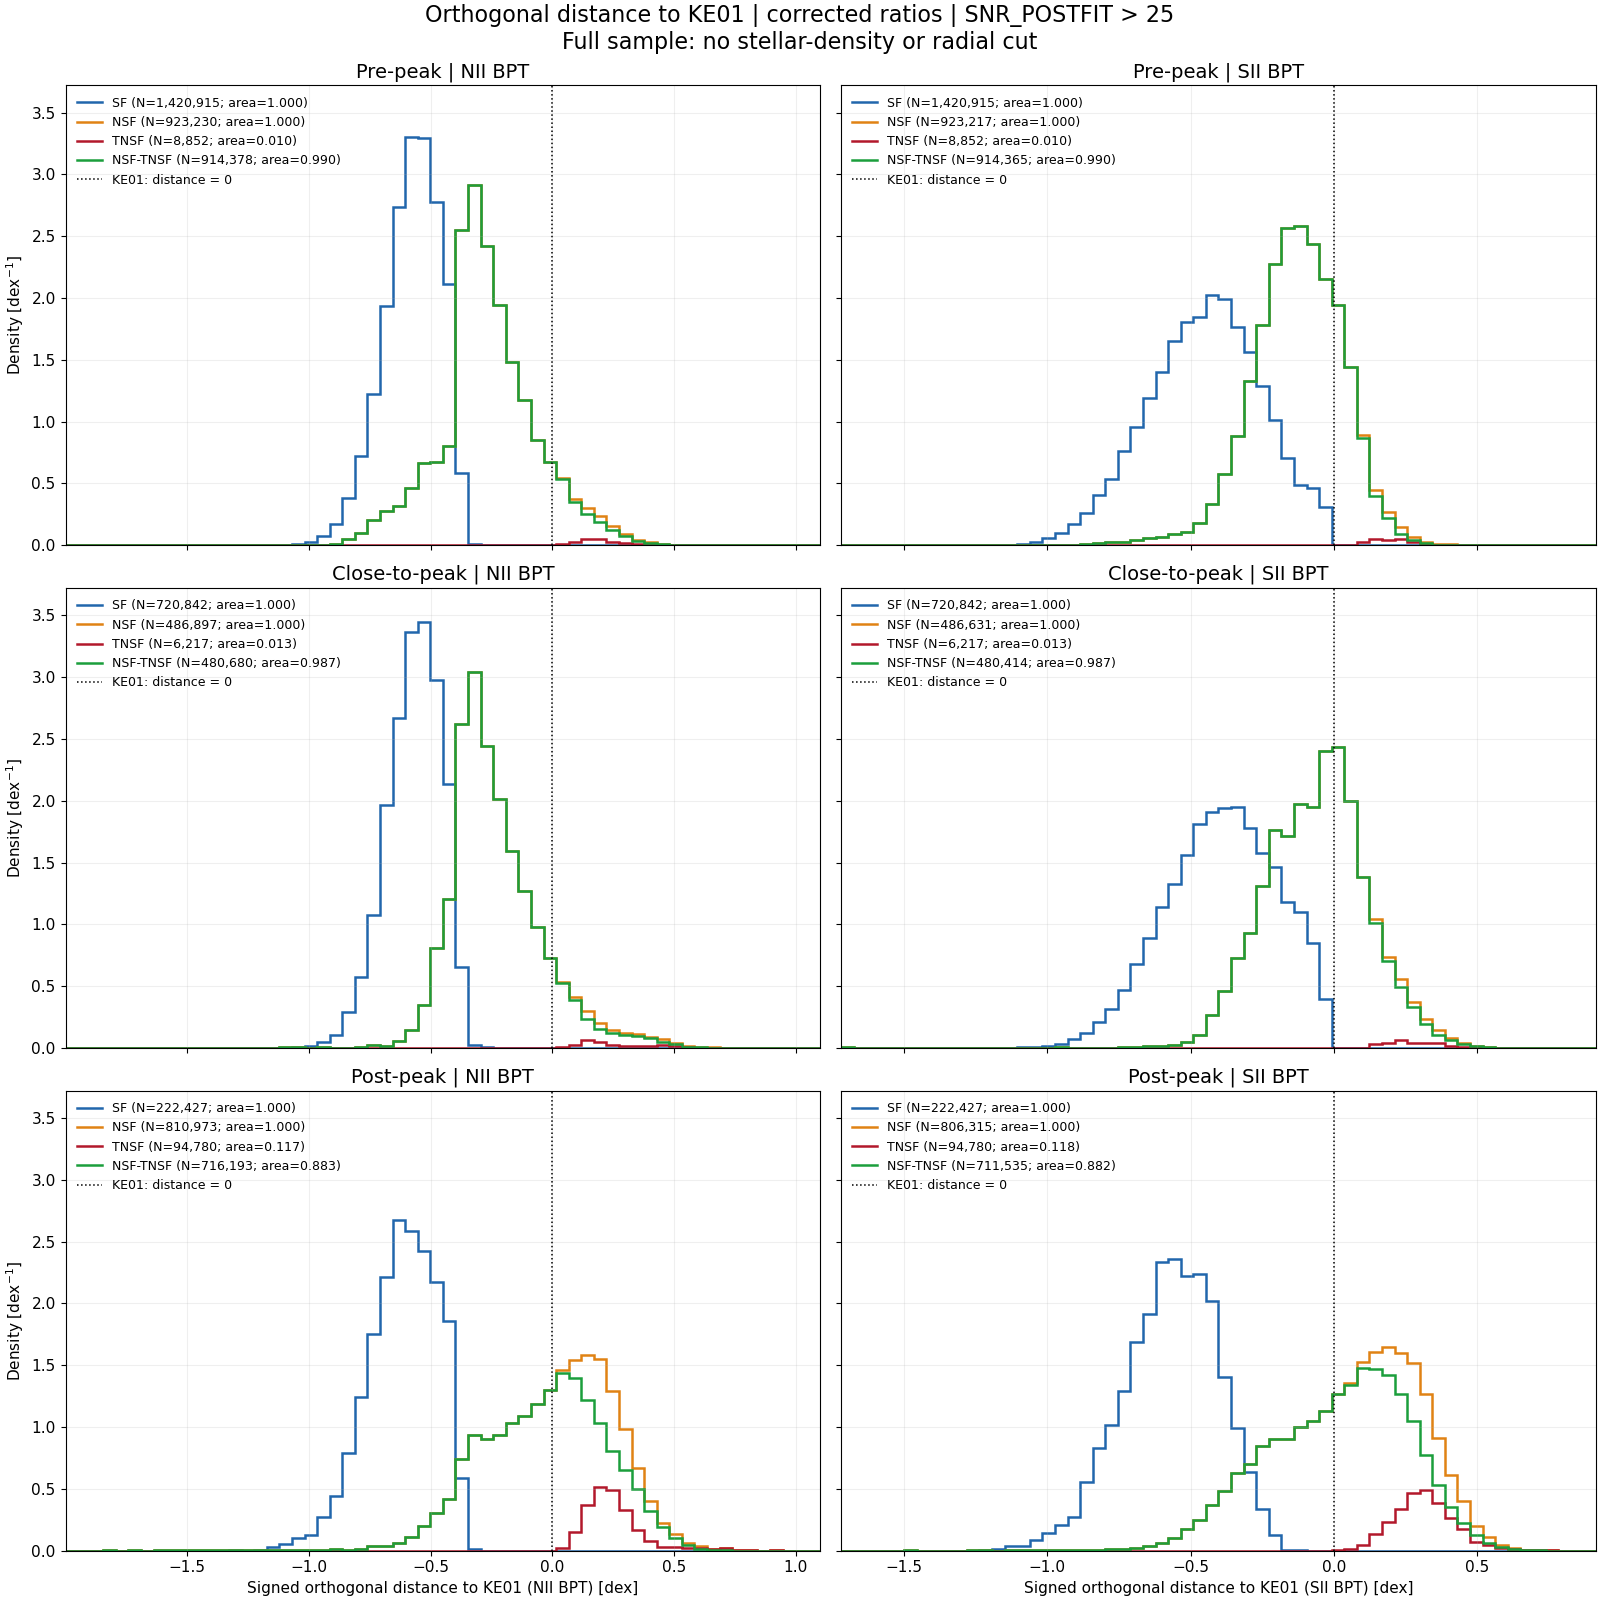

In [8]:
plot_combined_pdf(POOLED, "Full sample: no stellar-density or radial cut")


## Repeat by stellar surface density

Five separate figures; no additional radial cut. Stellar density uses `LOGMASS_SURFACE_DENSITY`, in log10(Msol/kpc2).



$ 7.0 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 7.5 $ | Pre-peak | NII | combined PDF
SF: N=122,112; distance range=[-0.951369, -0.325701] dex; median=-0.544069 dex; denominator=122,112; PDF integral=1
NSF: N=72,182; distance range=[-1.00197, 0.0132827] dex; median=-0.483081 dex; denominator=72,182; PDF integral=1
TNSF: N=0; denominator=72,182; integral=0.0; no finite paired distances
NSF-TNSF: N=72,182; distance range=[-1.00197, 0.0132827] dex; median=-0.483081 dex; denominator=72,182; PDF integral=1
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 7.0 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 7.5 $ | Pre-peak | SII | combined PDF
SF: N=122,112; distance range=[-0.803705, -0.00709875] dex; median=-0.235584 dex; denominator=122,112; PDF integral=1
NSF: N=72,182; distance range=[-0.946255, 0.227506] dex; median=-0.00182609 dex; denominator=72,182; PDF integral=1
TNSF: N=0; denominator=72,182; integral=0.0; no finite paired distances
NSF-TNSF: N=72,182; dist

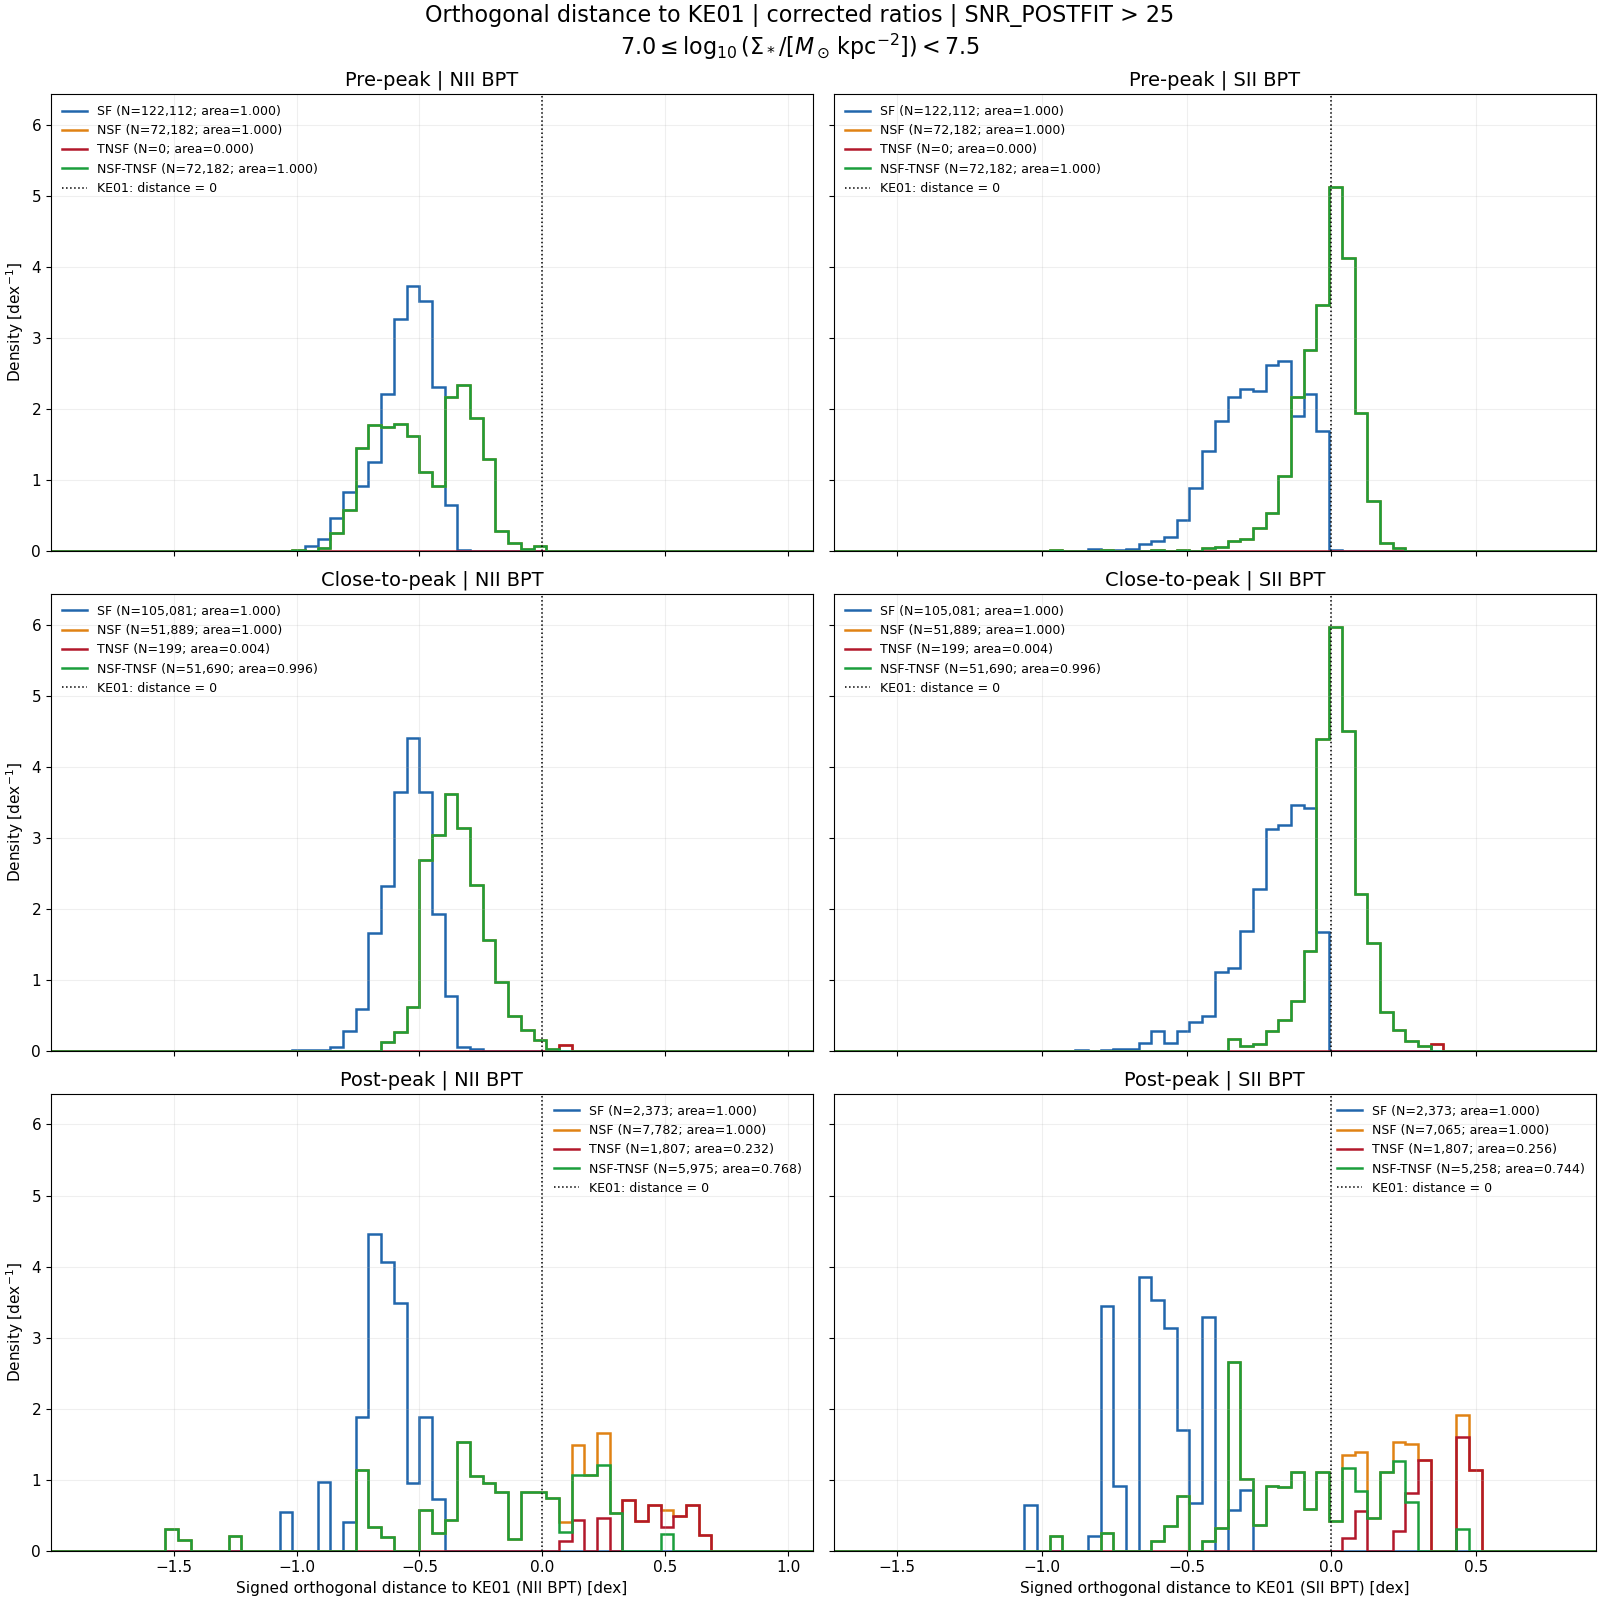

In [9]:
lower, upper = SIGMA_STAR_EDGES[0:2]
plot_combined_pdf(
    pool_interval("log_sigma_star", lower, upper),
    rf"$ {lower:.1f} \leq \log_{{10}}(\Sigma_*/[M_\odot\,\mathrm{{kpc}}^{{-2}}]) < {upper:.1f} $",
)



$ 7.5 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 8.0 $ | Pre-peak | NII | combined PDF
SF: N=603,748; distance range=[-1.05816, -0.258745] dex; median=-0.545758 dex; denominator=603,748; PDF integral=1
NSF: N=344,187; distance range=[-1.28191, 0.433338] dex; median=-0.313503 dex; denominator=344,187; PDF integral=1
TNSF: N=1,304; distance range=[0.0495463, 0.312908] dex; median=0.132443 dex; denominator=344,187; PDF integral=0.00378864
NSF-TNSF: N=342,883; distance range=[-1.28191, 0.433338] dex; median=-0.314095 dex; denominator=344,187; PDF integral=0.996211
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 7.5 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 8.0 $ | Pre-peak | SII | combined PDF
SF: N=603,748; distance range=[-1.15379, -0.00845788] dex; median=-0.383985 dex; denominator=603,748; PDF integral=1
NSF: N=344,187; distance range=[-1.37401, 0.428713] dex; median=-0.120462 dex; denominator=344,187; PDF integral=1
TNSF: N=1,304; distance range=[0.077108

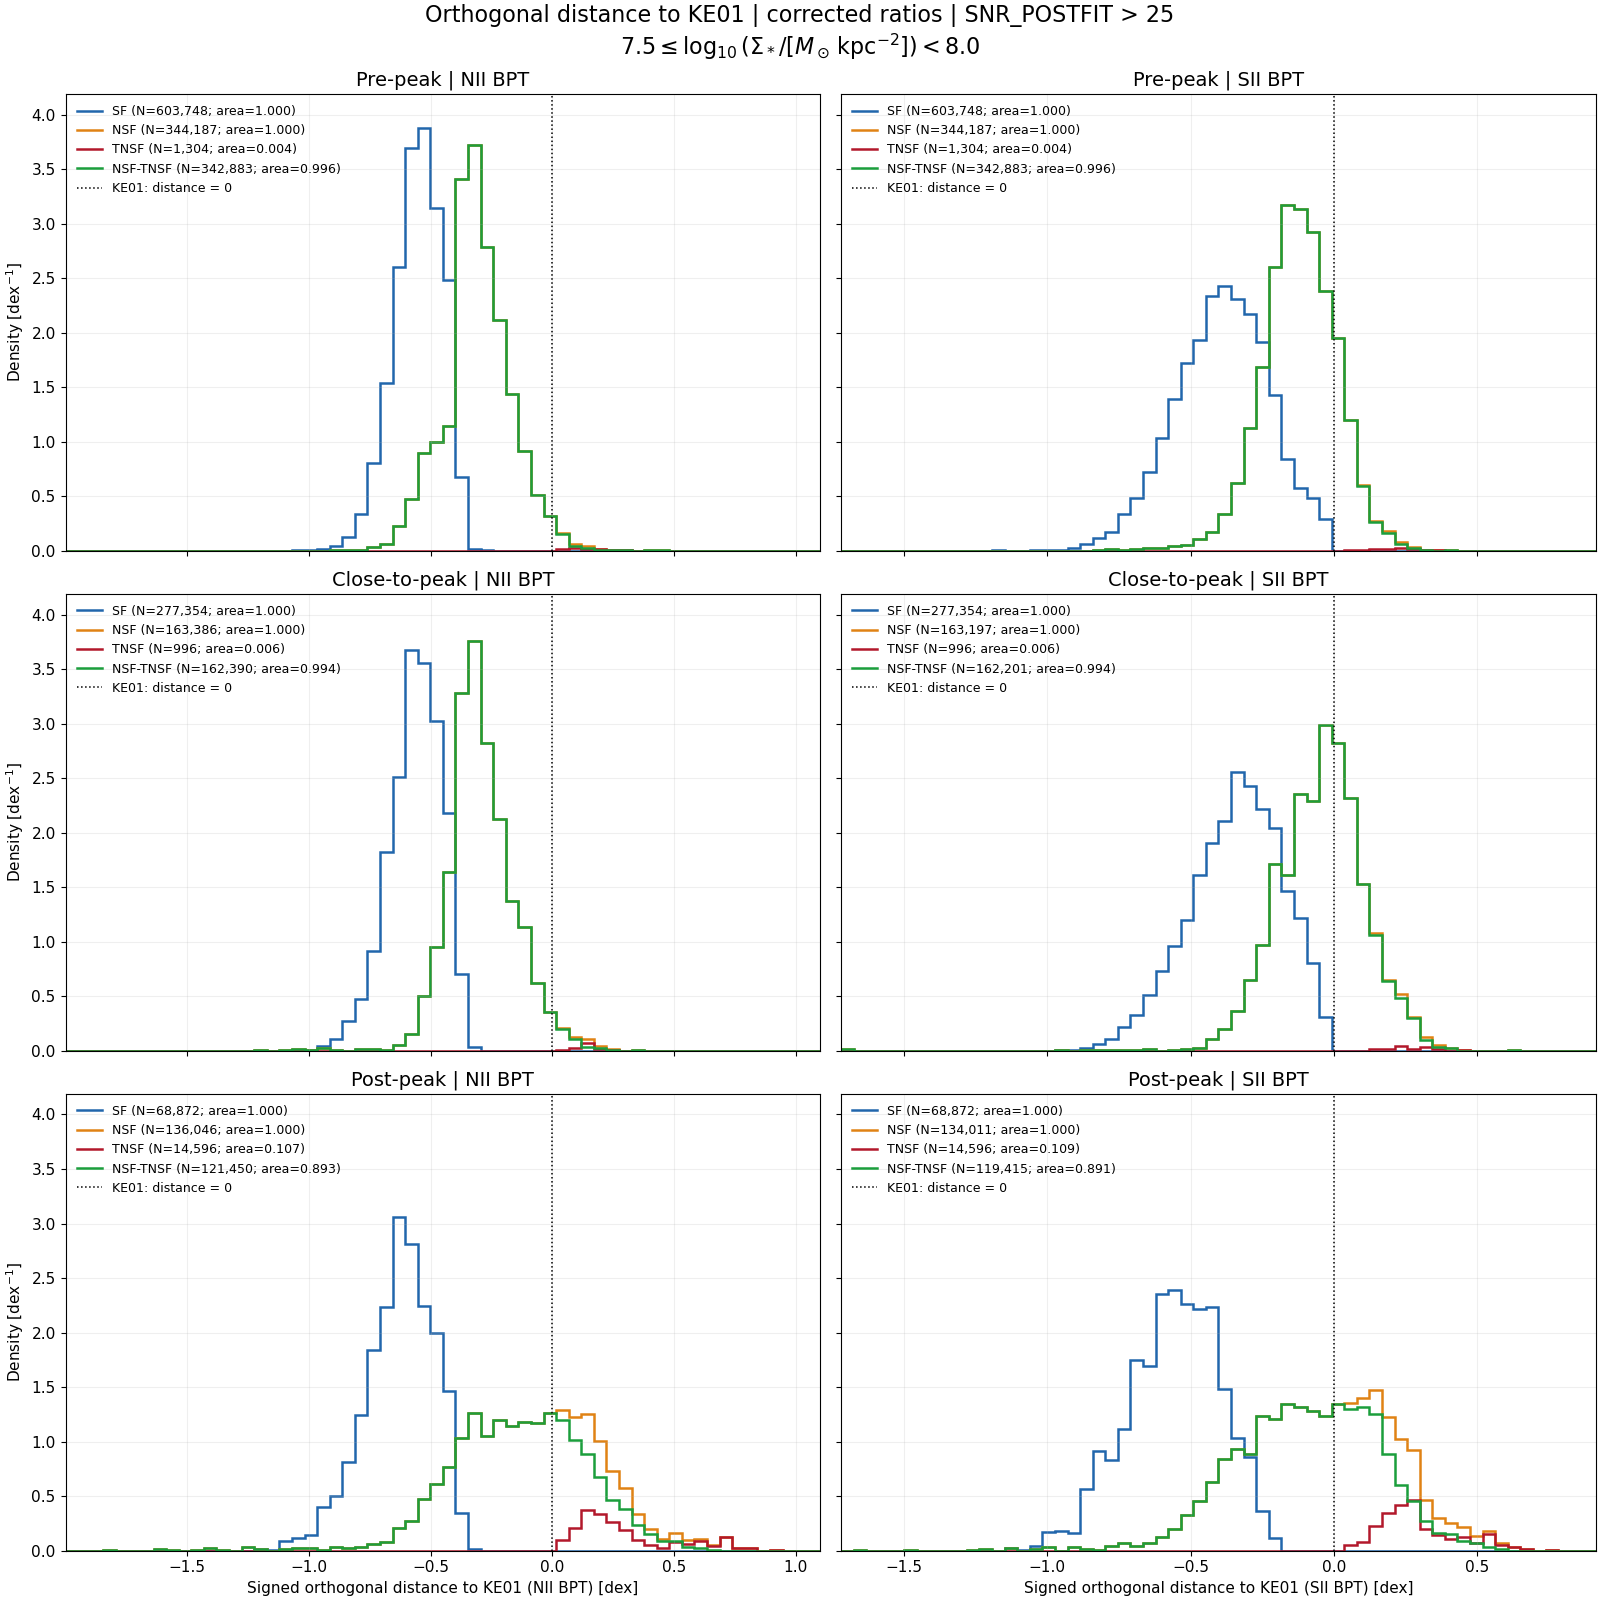

In [10]:
lower, upper = SIGMA_STAR_EDGES[1:3]
plot_combined_pdf(
    pool_interval("log_sigma_star", lower, upper),
    rf"$ {lower:.1f} \leq \log_{{10}}(\Sigma_*/[M_\odot\,\mathrm{{kpc}}^{{-2}}]) < {upper:.1f} $",
)



$ 8.0 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 8.5 $ | Pre-peak | NII | combined PDF
SF: N=546,737; distance range=[-1.11565, -0.222761] dex; median=-0.589291 dex; denominator=546,737; PDF integral=1
NSF: N=395,452; distance range=[-1.01331, 0.625836] dex; median=-0.230251 dex; denominator=395,452; PDF integral=1
TNSF: N=5,788; distance range=[0.0402216, 0.625836] dex; median=0.18172 dex; denominator=395,452; PDF integral=0.0146364
NSF-TNSF: N=389,664; distance range=[-1.01331, 0.558415] dex; median=-0.23362 dex; denominator=395,452; PDF integral=0.985364
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 8.0 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 8.5 $ | Pre-peak | SII | combined PDF
SF: N=546,737; distance range=[-1.16137, -0.0151245] dex; median=-0.517662 dex; denominator=546,737; PDF integral=1
NSF: N=395,439; distance range=[-1.33201, 0.686265] dex; median=-0.148229 dex; denominator=395,439; PDF integral=1
TNSF: N=5,788; distance range=[0.0357896, 0

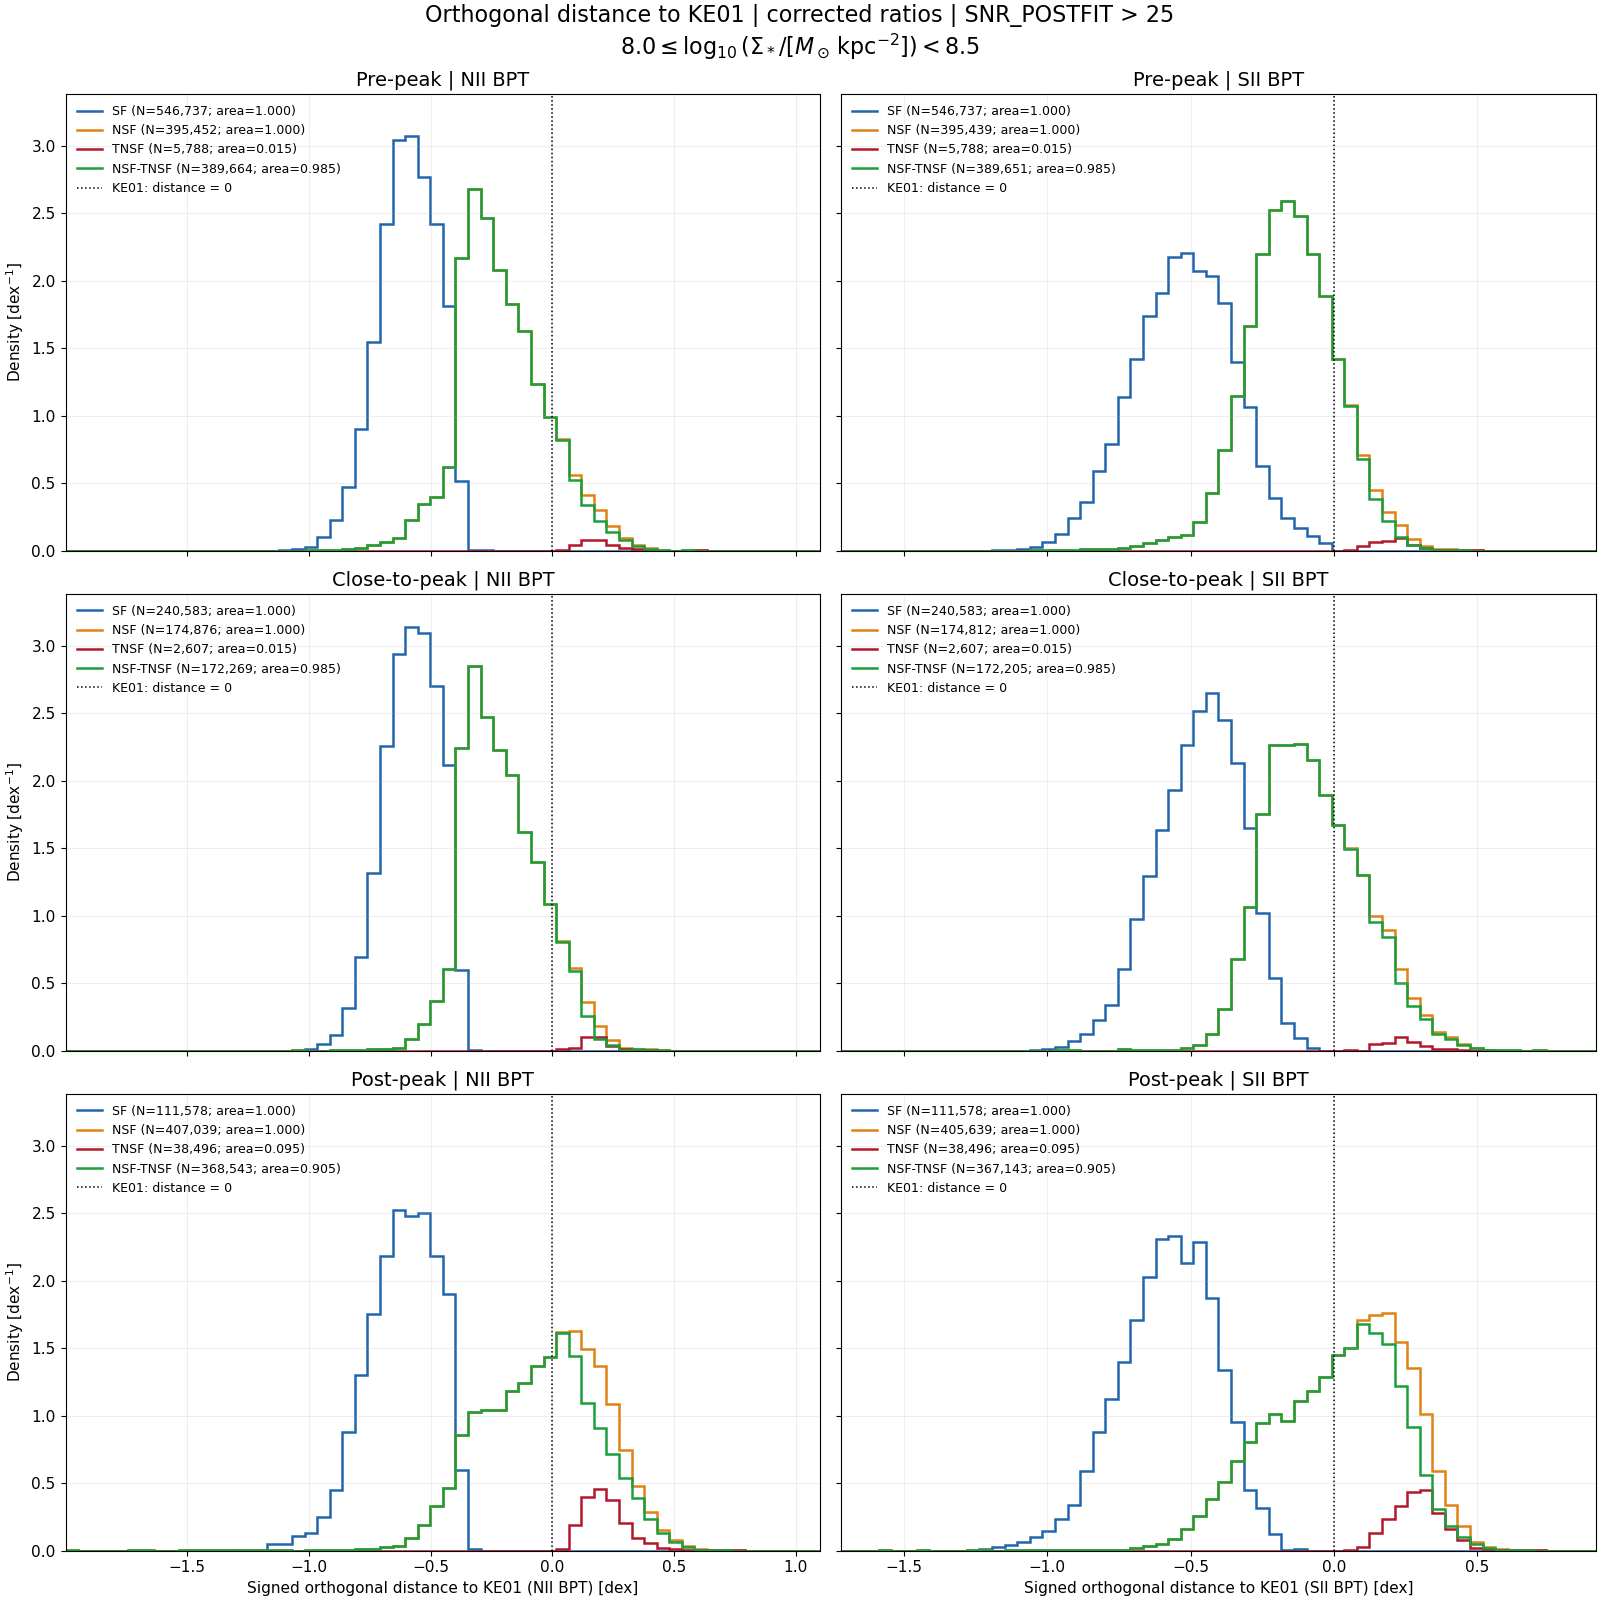

In [11]:
lower, upper = SIGMA_STAR_EDGES[2:4]
plot_combined_pdf(
    pool_interval("log_sigma_star", lower, upper),
    rf"$ {lower:.1f} \leq \log_{{10}}(\Sigma_*/[M_\odot\,\mathrm{{kpc}}^{{-2}}]) < {upper:.1f} $",
)



$ 8.5 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 9.0 $ | Pre-peak | NII | combined PDF
SF: N=120,923; distance range=[-1.08522, -0.348876] dex; median=-0.611023 dex; denominator=120,923; PDF integral=1
NSF: N=88,370; distance range=[-1.01426, 0.647383] dex; median=-0.120292 dex; denominator=88,370; PDF integral=1
TNSF: N=1,580; distance range=[0.0719127, 0.484064] dex; median=0.242461 dex; denominator=88,370; PDF integral=0.0178794
NSF-TNSF: N=86,790; distance range=[-1.01426, 0.647383] dex; median=-0.126582 dex; denominator=88,370; PDF integral=0.982121
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 8.5 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 9.0 $ | Pre-peak | SII | combined PDF
SF: N=120,923; distance range=[-1.23076, -0.0269319] dex; median=-0.606277 dex; denominator=120,923; PDF integral=1
NSF: N=88,370; distance range=[-1.35937, 0.453802] dex; median=-0.134944 dex; denominator=88,370; PDF integral=1
TNSF: N=1,580; distance range=[0.0324628, 0.4300

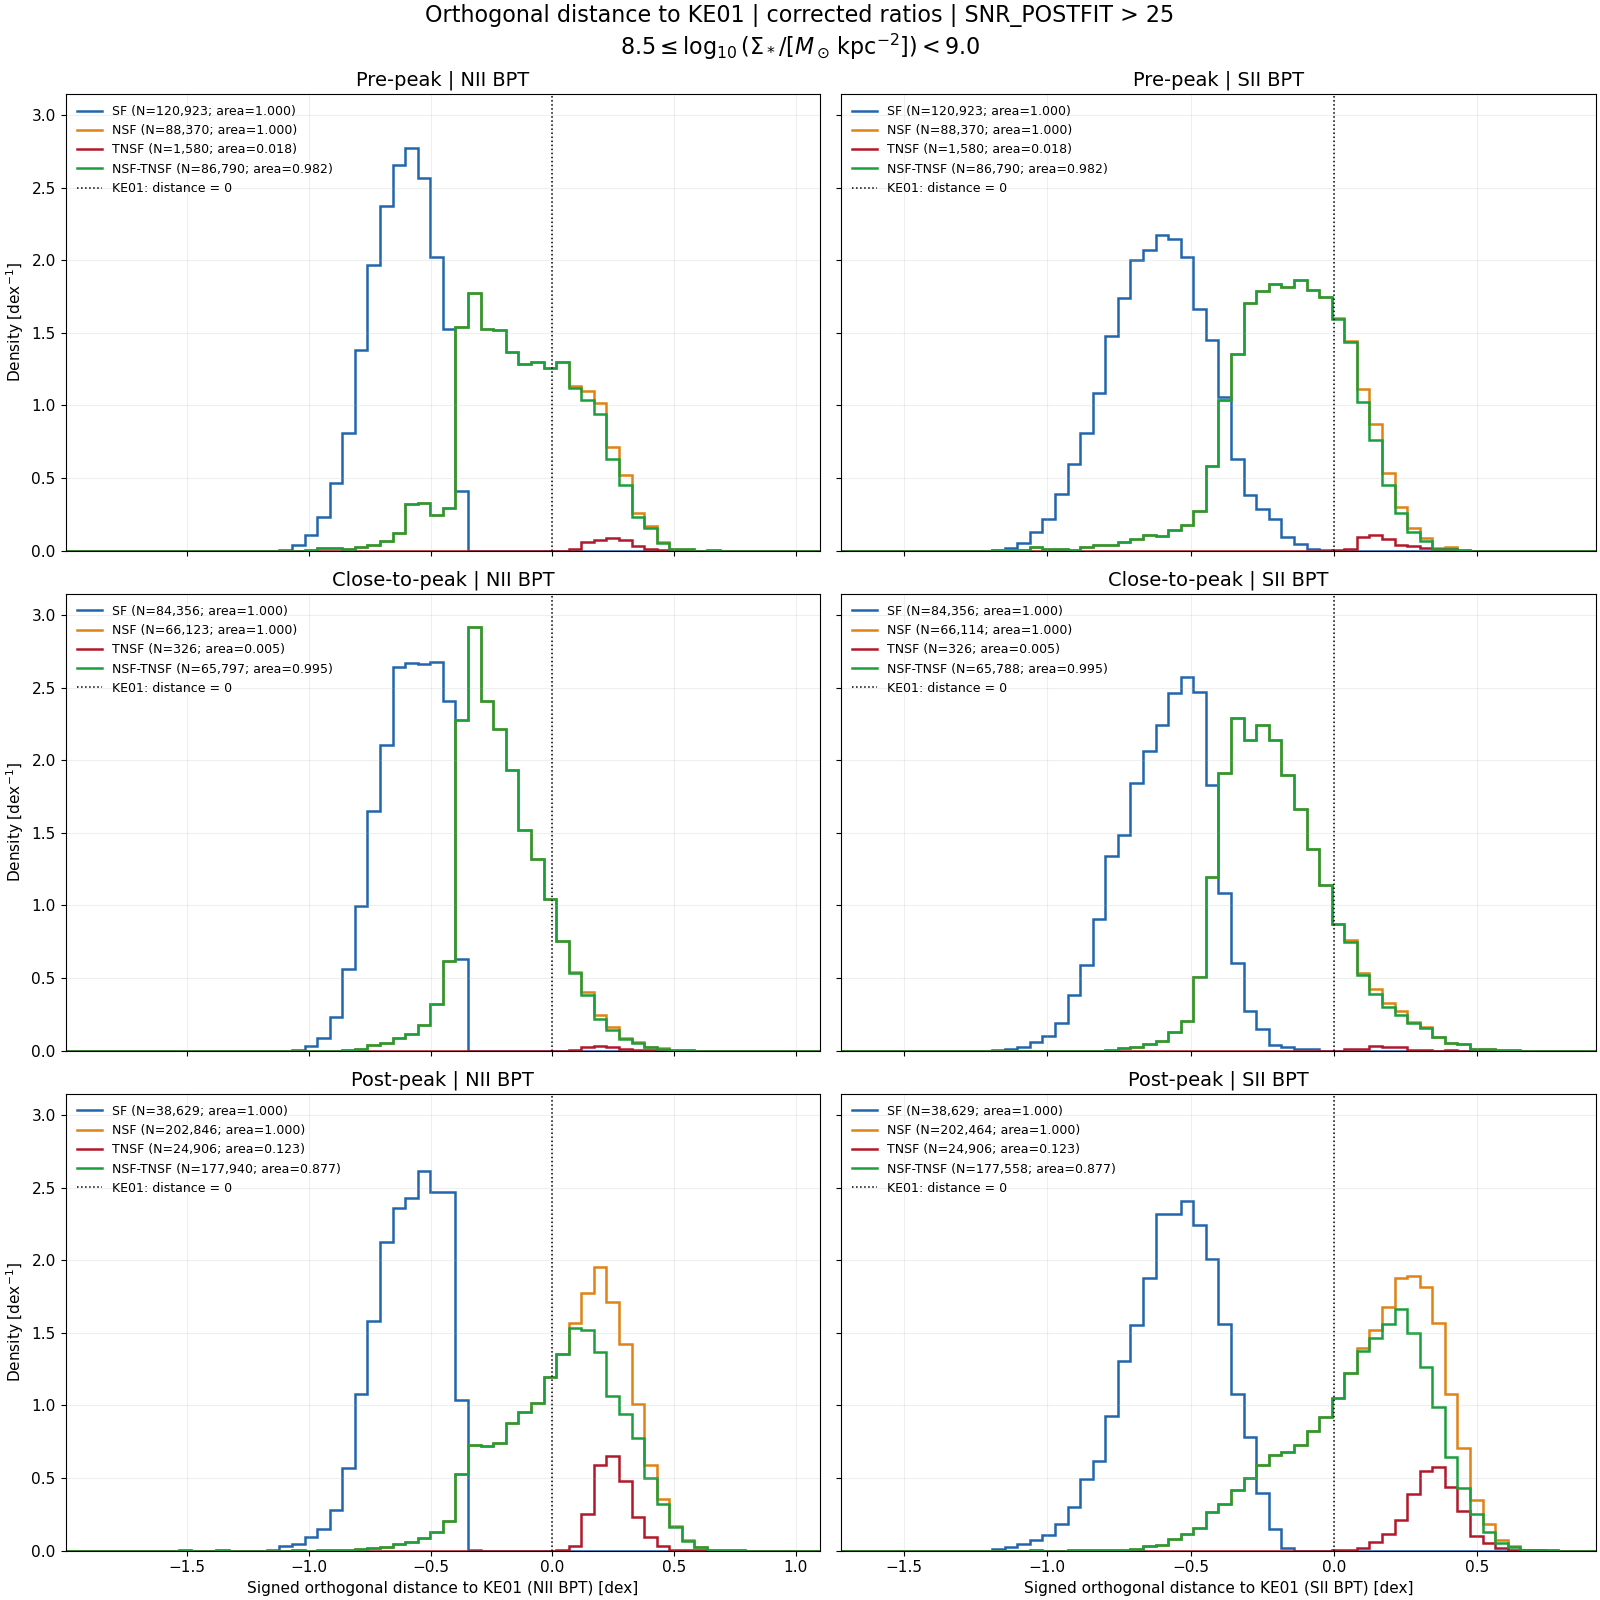

In [12]:
lower, upper = SIGMA_STAR_EDGES[3:5]
plot_combined_pdf(
    pool_interval("log_sigma_star", lower, upper),
    rf"$ {lower:.1f} \leq \log_{{10}}(\Sigma_*/[M_\odot\,\mathrm{{kpc}}^{{-2}}]) < {upper:.1f} $",
)



$ 9.0 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 9.5 $ | Pre-peak | NII | combined PDF
SF: N=19,292; distance range=[-1.0782, -0.359547] dex; median=-0.645848 dex; denominator=19,292; PDF integral=1
NSF: N=8,923; distance range=[-1.00308, 0.341839] dex; median=-0.353325 dex; denominator=8,923; PDF integral=1
TNSF: N=39; distance range=[0.102759, 0.262082] dex; median=0.167613 dex; denominator=8,923; PDF integral=0.00437073
NSF-TNSF: N=8,884; distance range=[-1.00308, 0.341839] dex; median=-0.354086 dex; denominator=8,923; PDF integral=0.995629
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 9.0 \leq \log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}]) < 9.5 $ | Pre-peak | SII | combined PDF
SF: N=19,292; distance range=[-1.16355, -0.166125] dex; median=-0.712395 dex; denominator=19,292; PDF integral=1
NSF: N=8,923; distance range=[-1.12611, 0.238518] dex; median=-0.427786 dex; denominator=8,923; PDF integral=1
TNSF: N=39; distance range=[0.0252193, 0.21222] dex; median=0.13

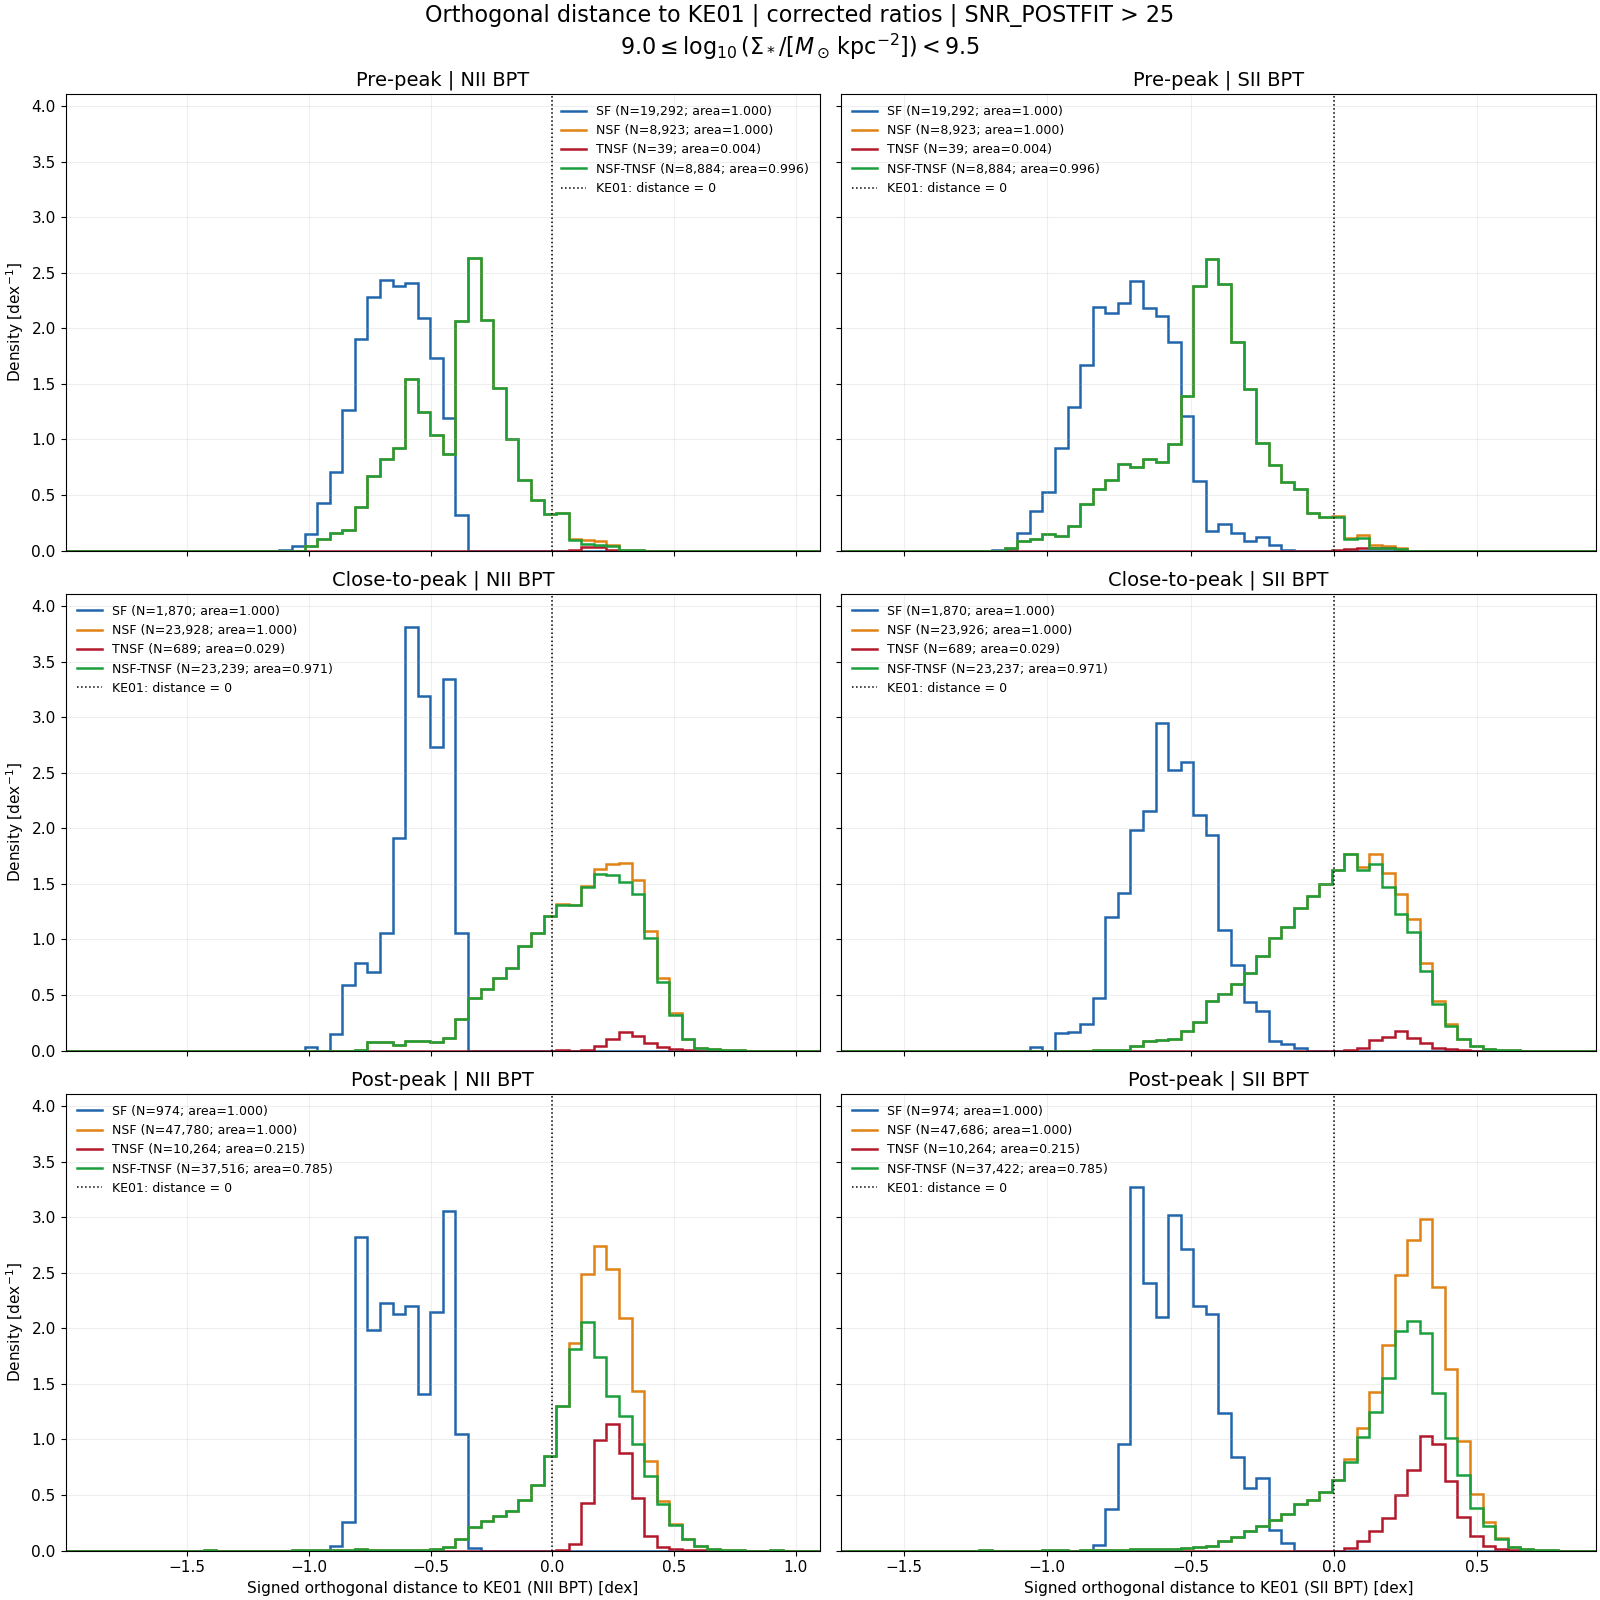

In [13]:
lower, upper = SIGMA_STAR_EDGES[4:6]
plot_combined_pdf(
    pool_interval("log_sigma_star", lower, upper),
    rf"$ {lower:.1f} \leq \log_{{10}}(\Sigma_*/[M_\odot\,\mathrm{{kpc}}^{{-2}}]) < {upper:.1f} $",
)


## Repeat by deprojected radius

Five separate figures; no additional stellar-density cut. Use the inherited `radius_re` map.



$ 0.0 \leq R/R_e < 0.5 $ | Pre-peak | NII | combined PDF
SF: N=170,009; distance range=[-1.10583, -0.222761] dex; median=-0.621932 dex; denominator=170,009; PDF integral=1
NSF: N=212,368; distance range=[-1.01426, 0.673442] dex; median=-0.106313 dex; denominator=212,368; PDF integral=1
TNSF: N=3,124; distance range=[0.0668834, 0.673442] dex; median=0.228926 dex; denominator=212,368; PDF integral=0.0147103
NSF-TNSF: N=209,244; distance range=[-1.01426, 0.647383] dex; median=-0.111221 dex; denominator=212,368; PDF integral=0.98529
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 0.0 \leq R/R_e < 0.5 $ | Pre-peak | SII | combined PDF
SF: N=170,009; distance range=[-1.23076, -0.0170168] dex; median=-0.627208 dex; denominator=170,009; PDF integral=1
NSF: N=212,355; distance range=[-1.35937, 0.501186] dex; median=-0.135376 dex; denominator=212,355; PDF integral=1
TNSF: N=3,124; distance range=[0.0252193, 0.501186] dex; median=0.16818 dex; denominator=212,355; PDF integral=0.0147112
NSF-TNS

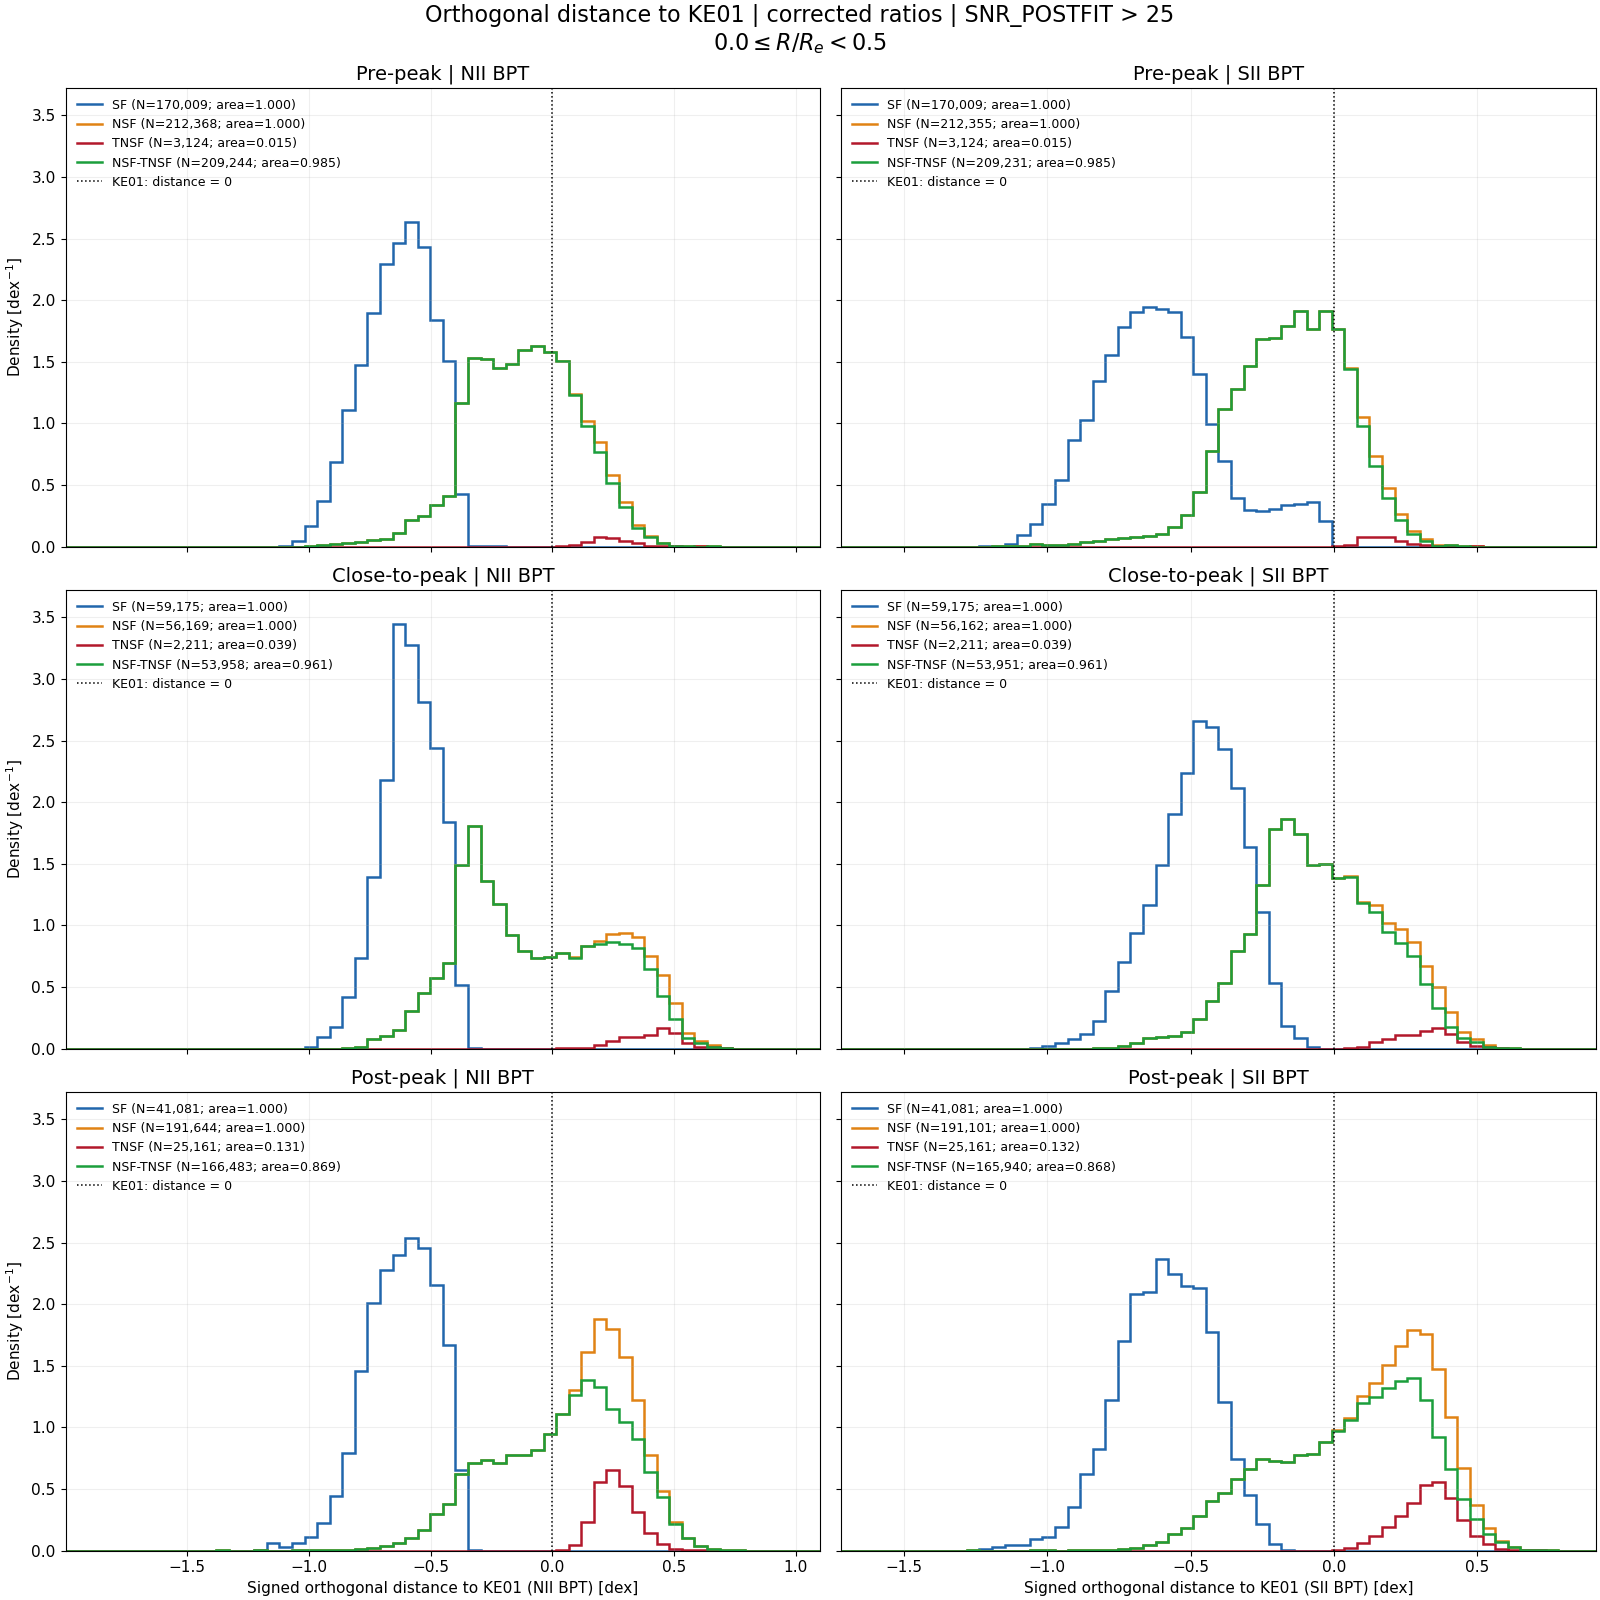

In [14]:
lower, upper = RADIAL_EDGES[0:2]
plot_combined_pdf(
    pool_interval("radius_re", lower, upper),
    rf"$ {lower:.1f} \leq R/R_e < {upper:.1f} $",
)



$ 0.5 \leq R/R_e < 1.0 $ | Pre-peak | NII | combined PDF
SF: N=563,149; distance range=[-1.11565, -0.288536] dex; median=-0.580246 dex; denominator=563,149; PDF integral=1
NSF: N=383,785; distance range=[-1.01331, 0.433338] dex; median=-0.270027 dex; denominator=383,785; PDF integral=1
TNSF: N=2,535; distance range=[0.0402216, 0.414208] dex; median=0.16911 dex; denominator=383,785; PDF integral=0.00660526
NSF-TNSF: N=381,250; distance range=[-1.01331, 0.433338] dex; median=-0.271223 dex; denominator=383,785; PDF integral=0.993395
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 0.5 \leq R/R_e < 1.0 $ | Pre-peak | SII | combined PDF
SF: N=563,149; distance range=[-1.15379, -0.00845788] dex; median=-0.495822 dex; denominator=563,149; PDF integral=1
NSF: N=383,785; distance range=[-1.16391, 0.686265] dex; median=-0.155111 dex; denominator=383,785; PDF integral=1
TNSF: N=2,535; distance range=[0.0675371, 0.433823] dex; median=0.226704 dex; denominator=383,785; PDF integral=0.00660526
NSF

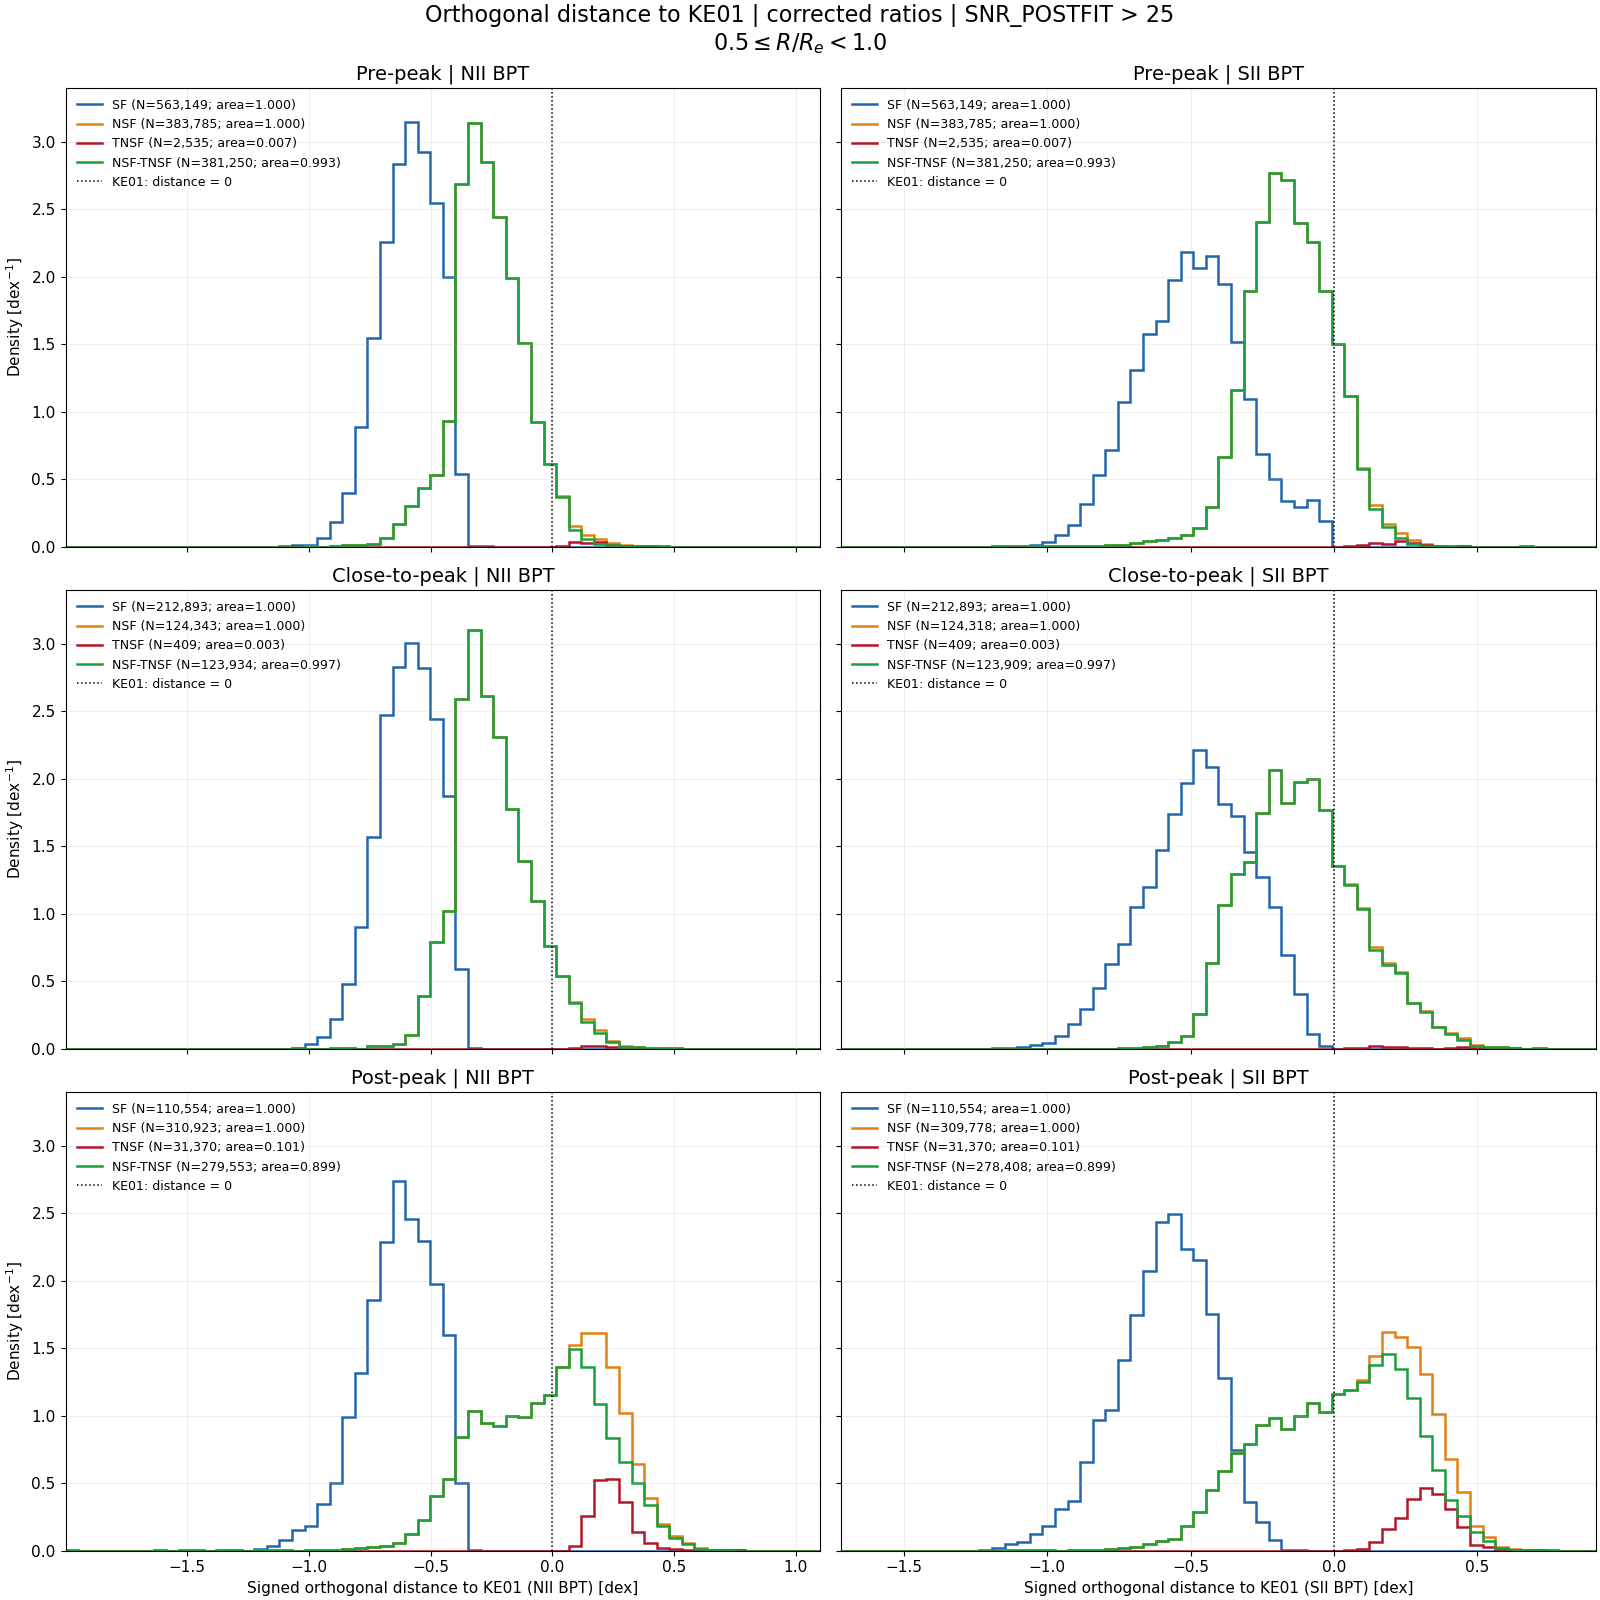

In [15]:
lower, upper = RADIAL_EDGES[1:3]
plot_combined_pdf(
    pool_interval("radius_re", lower, upper),
    rf"$ {lower:.1f} \leq R/R_e < {upper:.1f} $",
)



$ 1.0 \leq R/R_e < 1.5 $ | Pre-peak | NII | combined PDF
SF: N=398,315; distance range=[-1.02474, -0.258745] dex; median=-0.565853 dex; denominator=398,315; PDF integral=1
NSF: N=182,504; distance range=[-1.28191, 0.419766] dex; median=-0.320596 dex; denominator=182,504; PDF integral=1
TNSF: N=3,002; distance range=[0.0537518, 0.341116] dex; median=0.159189 dex; denominator=182,504; PDF integral=0.016449
NSF-TNSF: N=179,502; distance range=[-1.28191, 0.419766] dex; median=-0.322978 dex; denominator=182,504; PDF integral=0.983551
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 1.0 \leq R/R_e < 1.5 $ | Pre-peak | SII | combined PDF
SF: N=398,315; distance range=[-1.05422, -0.00709875] dex; median=-0.404095 dex; denominator=398,315; PDF integral=1
NSF: N=182,504; distance range=[-1.37401, 0.430018] dex; median=-0.117818 dex; denominator=182,504; PDF integral=1
TNSF: N=3,002; distance range=[0.0621962, 0.430018] dex; median=0.212179 dex; denominator=182,504; PDF integral=0.016449
NSF-TN

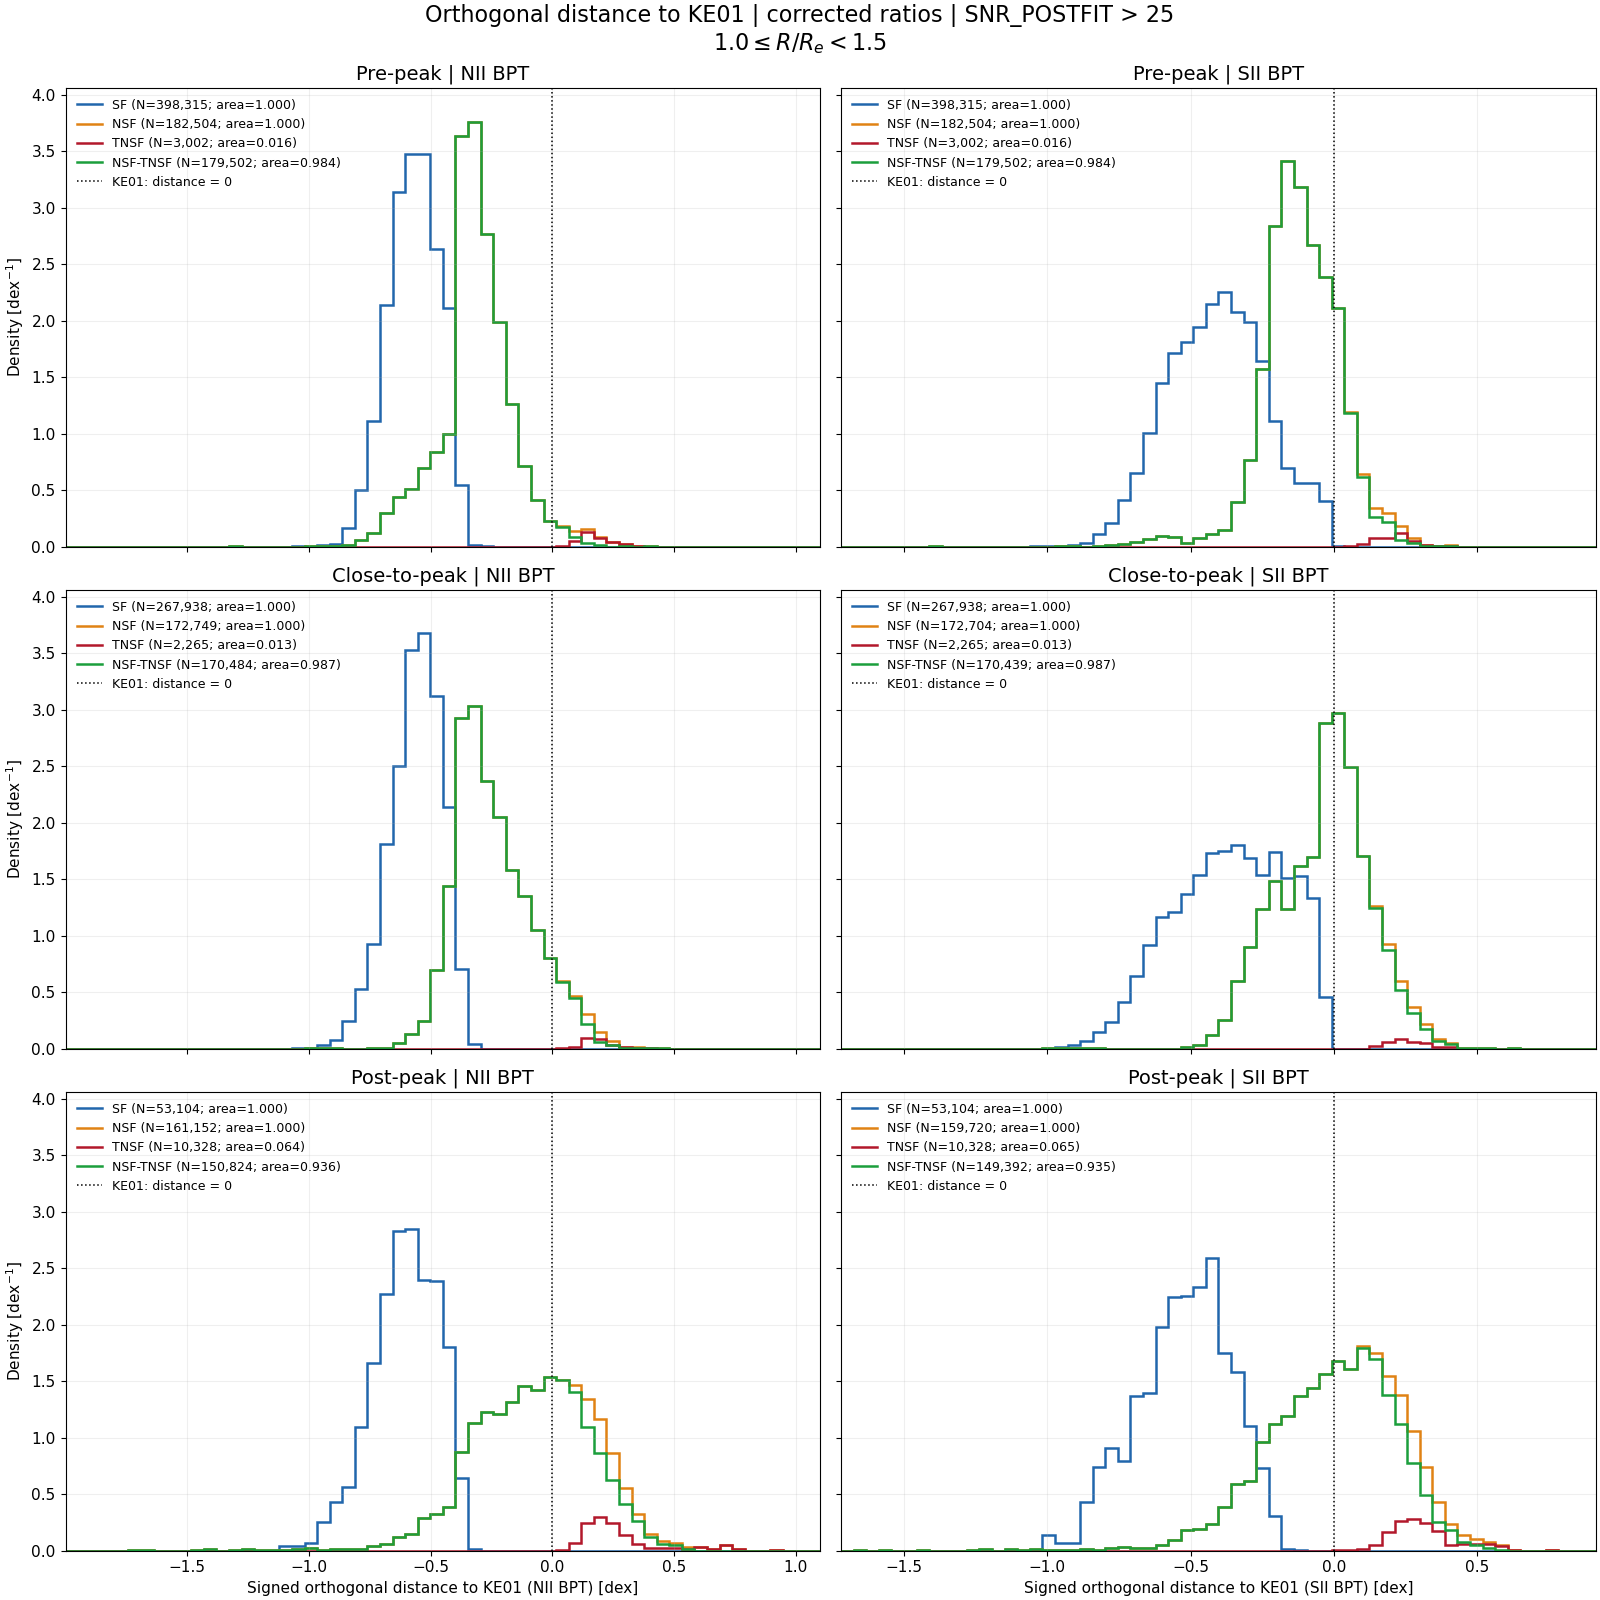

In [16]:
lower, upper = RADIAL_EDGES[2:4]
plot_combined_pdf(
    pool_interval("radius_re", lower, upper),
    rf"$ {lower:.1f} \leq R/R_e < {upper:.1f} $",
)



$ 1.5 \leq R/R_e < 2.0 $ | Pre-peak | NII | combined PDF
SF: N=177,830; distance range=[-0.946495, -0.350114] dex; median=-0.540287 dex; denominator=177,830; PDF integral=1
NSF: N=86,086; distance range=[-0.872813, 0.248878] dex; median=-0.365663 dex; denominator=86,086; PDF integral=1
TNSF: N=191; distance range=[0.0670316, 0.248878] dex; median=0.138606 dex; denominator=86,086; PDF integral=0.00221871
NSF-TNSF: N=85,895; distance range=[-0.872813, 0.0548388] dex; median=-0.366141 dex; denominator=86,086; PDF integral=0.997781
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 1.5 \leq R/R_e < 2.0 $ | Pre-peak | SII | combined PDF
SF: N=177,830; distance range=[-0.836859, -0.00709875] dex; median=-0.335225 dex; denominator=177,830; PDF integral=1
NSF: N=86,086; distance range=[-0.765569, 0.273024] dex; median=-0.0599491 dex; denominator=86,086; PDF integral=1
TNSF: N=191; distance range=[0.103991, 0.273024] dex; median=0.146346 dex; denominator=86,086; PDF integral=0.00221871
NSF-TNSF

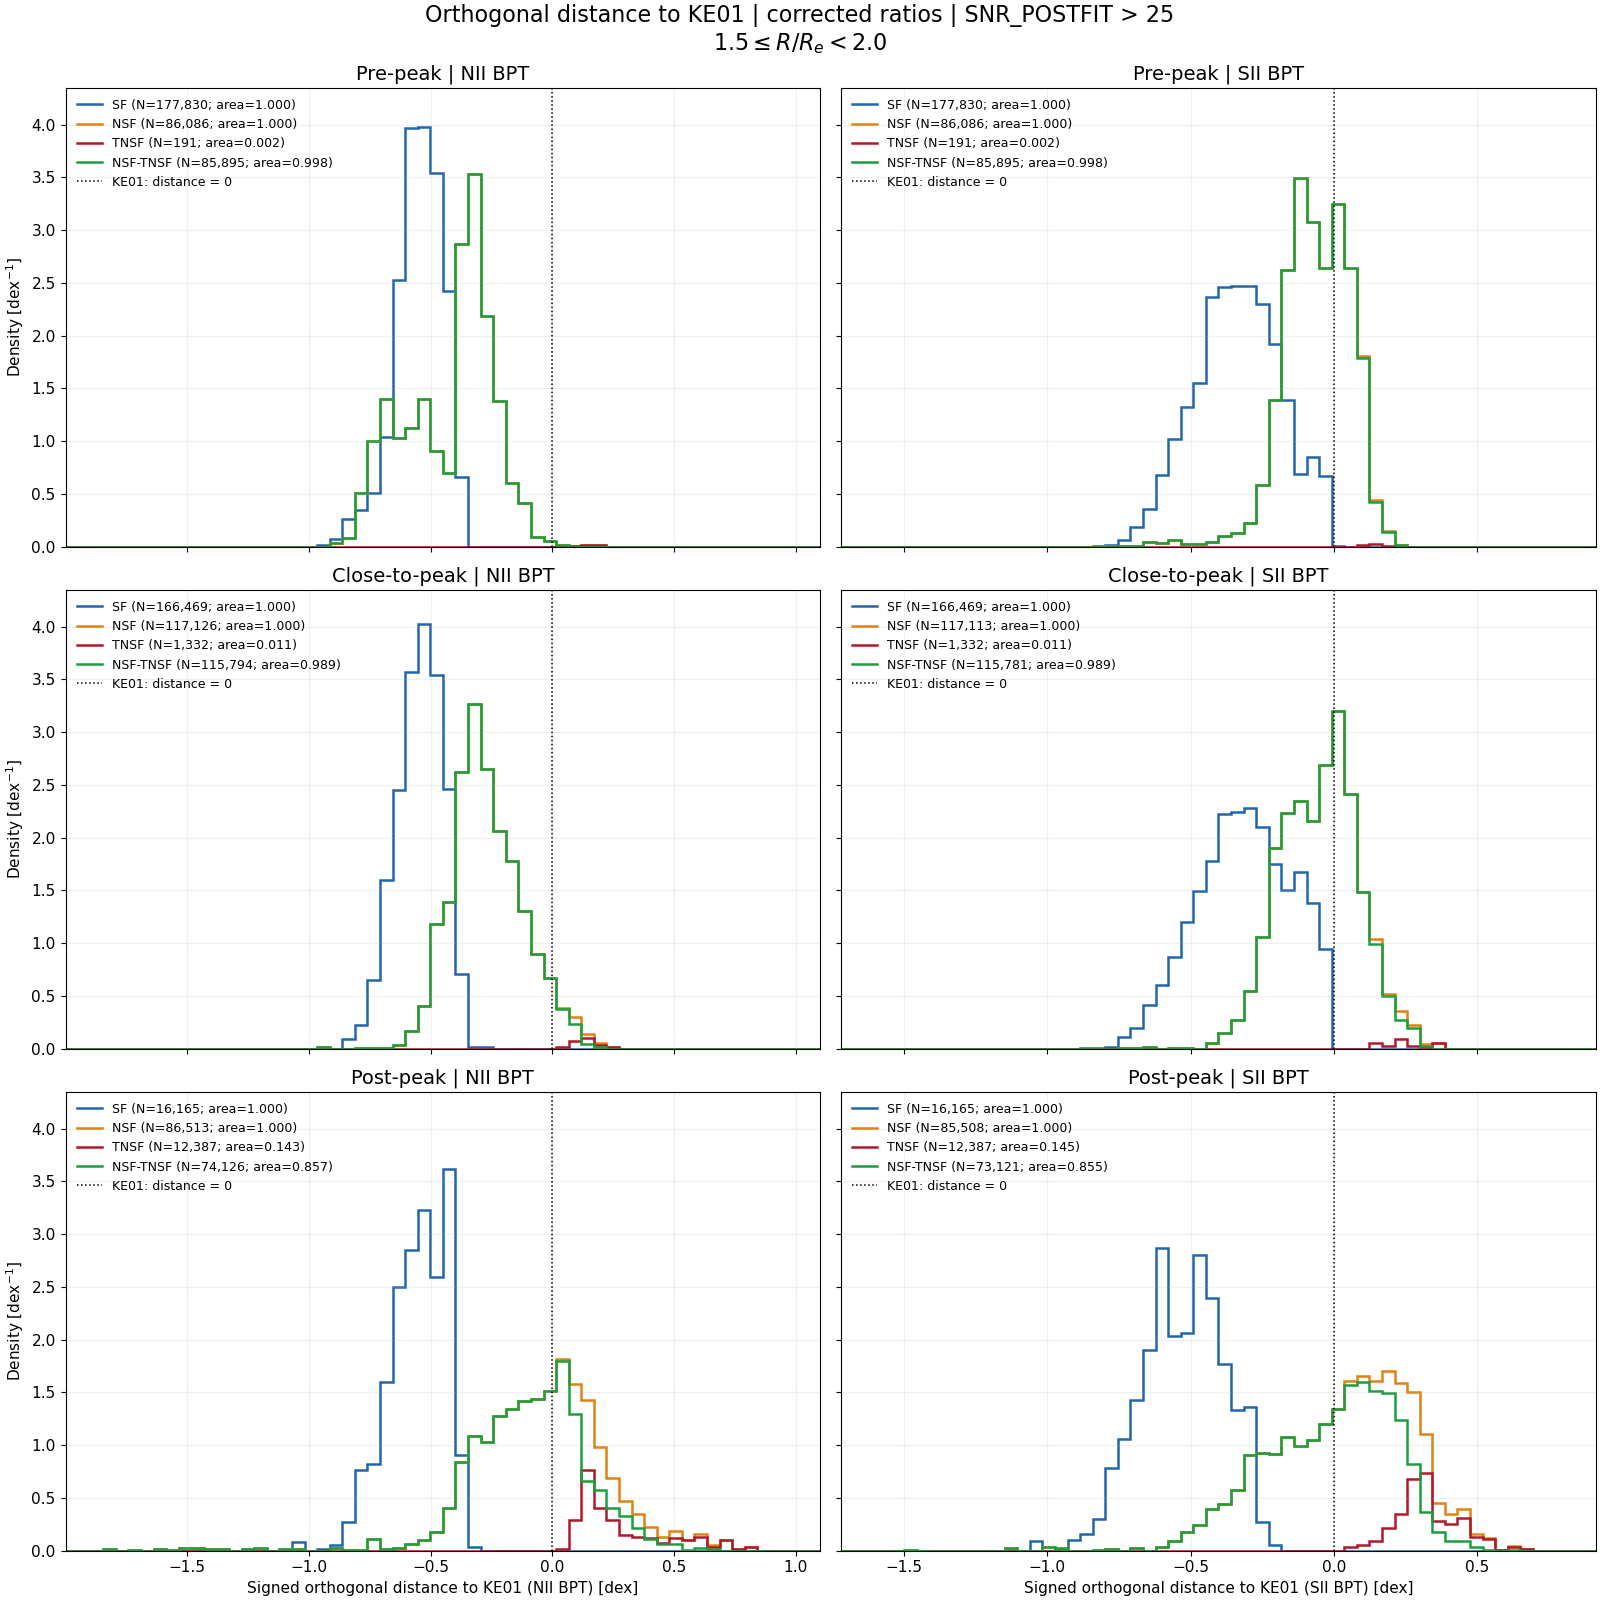

In [17]:
lower, upper = RADIAL_EDGES[3:5]
plot_combined_pdf(
    pool_interval("radius_re", lower, upper),
    rf"$ {lower:.1f} \leq R/R_e < {upper:.1f} $",
)



$ 2.0 \leq R/R_e < 2.5 $ | Pre-peak | NII | combined PDF
SF: N=84,070; distance range=[-0.871111, -0.354565] dex; median=-0.507072 dex; denominator=84,070; PDF integral=1
NSF: N=49,650; distance range=[-0.861829, 0.0548388] dex; median=-0.403001 dex; denominator=49,650; PDF integral=1
TNSF: N=0; denominator=49,650; integral=0.0; no finite paired distances
NSF-TNSF: N=49,650; distance range=[-0.861829, 0.0548388] dex; median=-0.403001 dex; denominator=49,650; PDF integral=1
Bin-by-bin check passed: TNSF + NSF-TNSF = NSF

$ 2.0 \leq R/R_e < 2.5 $ | Pre-peak | SII | combined PDF
SF: N=84,070; distance range=[-0.778973, -0.0356711] dex; median=-0.299766 dex; denominator=84,070; PDF integral=1
NSF: N=49,650; distance range=[-0.664385, 0.227506] dex; median=-0.0528868 dex; denominator=49,650; PDF integral=1
TNSF: N=0; denominator=49,650; integral=0.0; no finite paired distances
NSF-TNSF: N=49,650; distance range=[-0.664385, 0.227506] dex; median=-0.0528868 dex; denominator=49,650; PDF integ

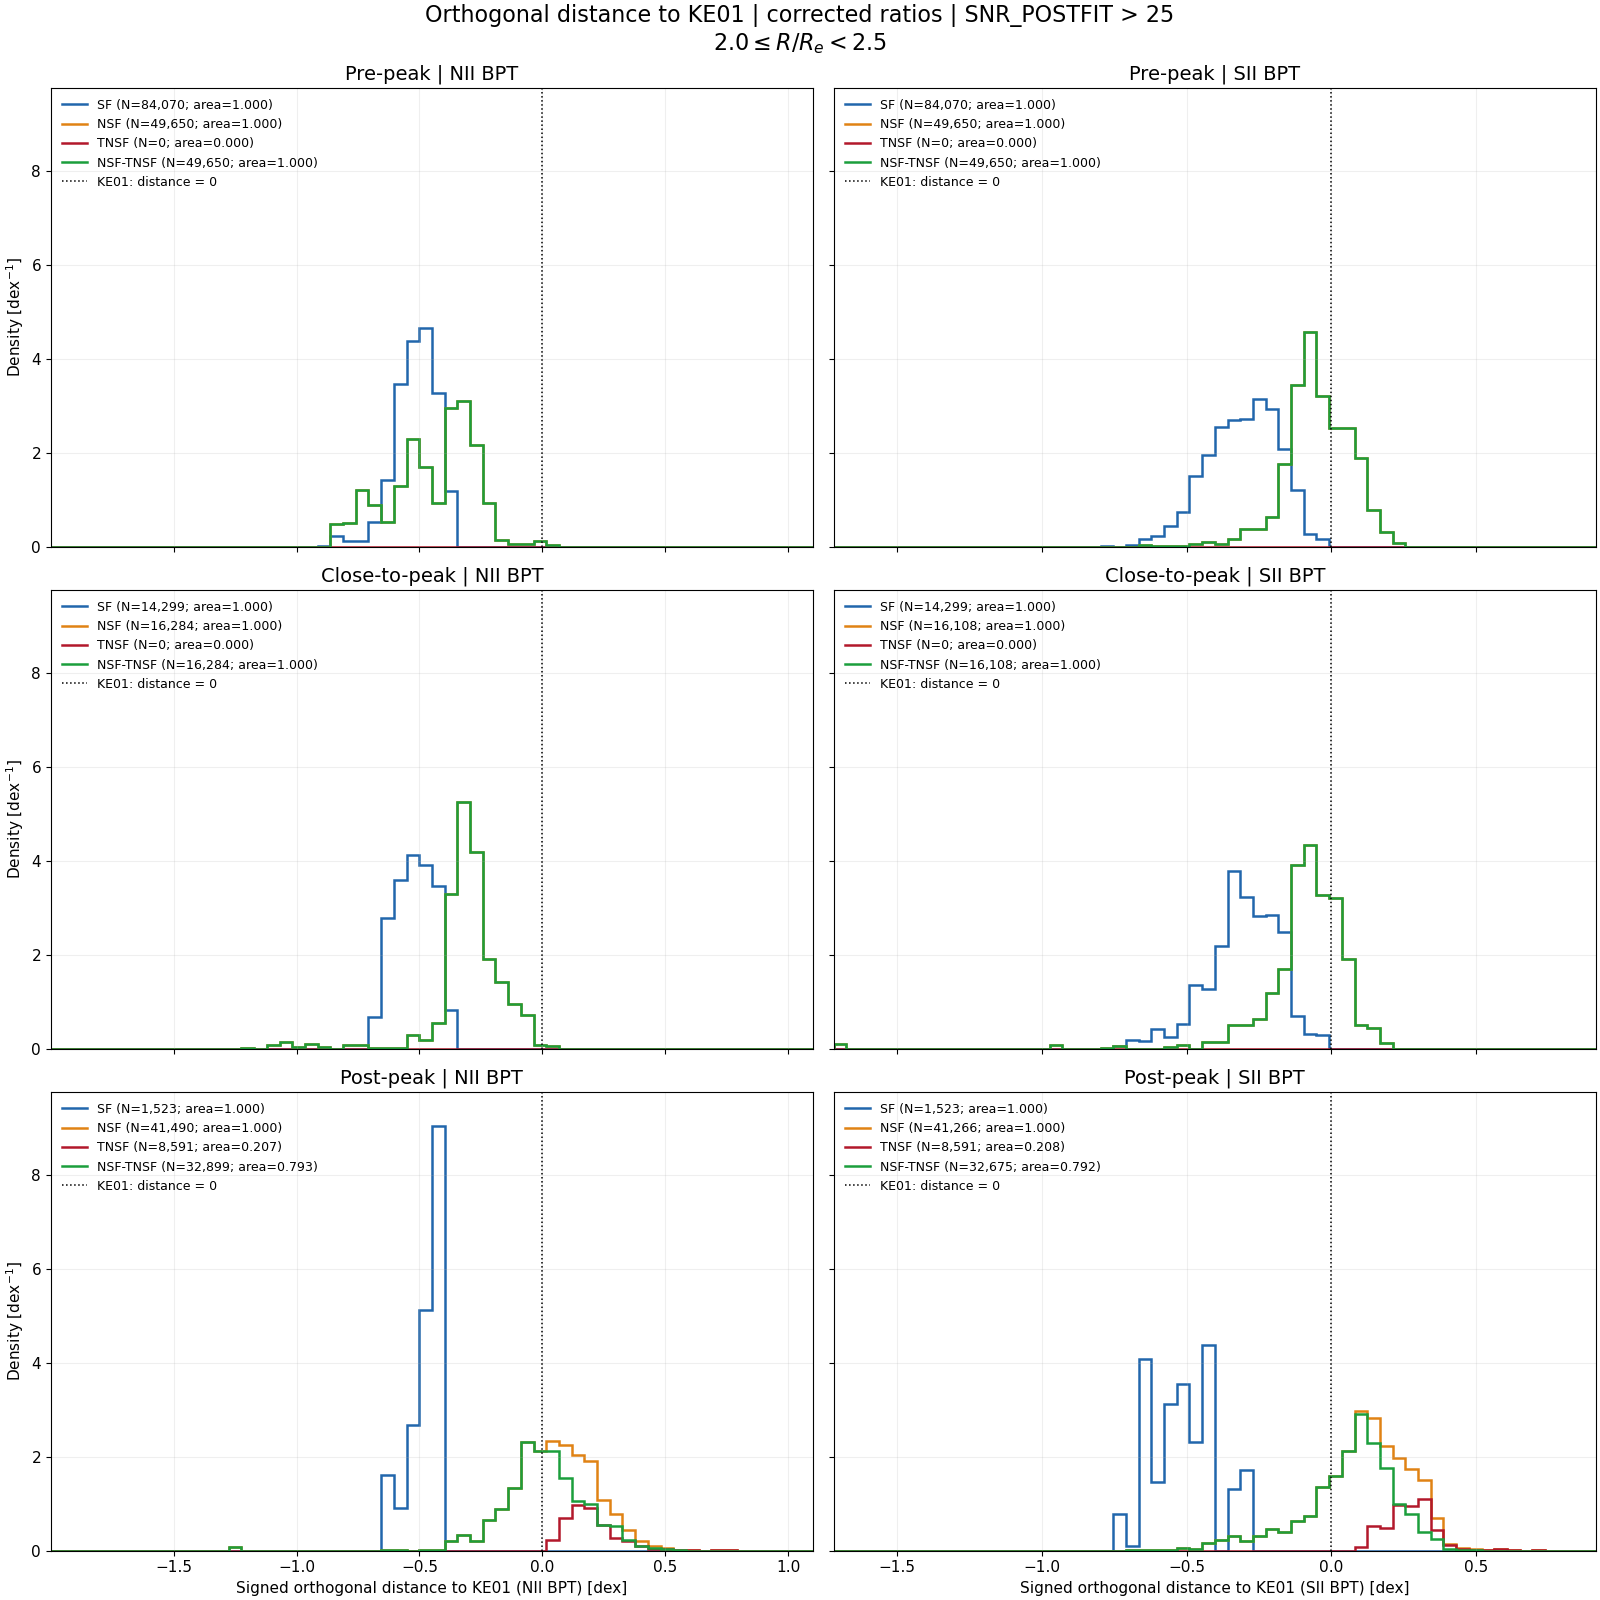

In [18]:
lower, upper = RADIAL_EDGES[4:6]
plot_combined_pdf(
    pool_interval("radius_re", lower, upper),
    rf"$ {lower:.1f} \leq R/R_e < {upper:.1f} $",
)
